# IPL Player Valuation

This notebook analyses batting and bowling statistics of players who
were bought at the 2025 IPL auction and compares each player's
measured performance against the price paid. The output is a
value-efficiency classification that identifies high-value
acquisitions, high-priced elite buys and low-cost / low-impact
selections, and translates these into shortlists a franchise auction
desk can act on.

**Contents**

1. Setup and data preprocessing
2. Exploratory data analysis
3. Performance score and tiers
4. Classification (Logistic Regression, Random Forest)
5. K-Means value clustering
6. Business insights and recommendations

## 1. Setup and data preprocessing

### 1.1 Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FINAL_CSV = PROJECT_ROOT / "data" / "final" / "ipl_player_dataset.csv"
RAW_AUCTION_CSV = PROJECT_ROOT / "data" / "raw" / "ipl_2025_auction_raw.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Final CSV    :", FINAL_CSV.relative_to(PROJECT_ROOT), "exists:", FINAL_CSV.exists())
print("Raw auction  :", RAW_AUCTION_CSV.relative_to(PROJECT_ROOT), "exists:", RAW_AUCTION_CSV.exists())


Project root : c:\Users\ramakrishanu\Documents\anusanth\ba\case-study\ipl-player-valuation
Final CSV    : data\final\ipl_player_dataset.csv exists: True
Raw auction  : data\raw\ipl_2025_auction_raw.csv exists: True


### 1.2 Load the integrated dataset

Reads the integrated CSV produced by the scraper pipeline
(`main.py` → `build_final_dataset.py`).

In [2]:
raw_df = pd.read_csv(FINAL_CSV)
print("Shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())
raw_df.head(5)


Shape: (164, 31)
Columns: ['Player', 'Span', 'Mat', 'Bat_Inns', 'NO', 'Bat_Runs', 'HS', 'Bat_Ave', 'BF', 'Bat_SR', '100', '50', '0', '4s', '6s', 'Bowl_Inns', 'Overs', 'Mdns', 'Bowl_Runs', 'Wkts', 'BBI', 'Bowl_Ave', 'Econ', 'Bowl_SR', '4W', '5W', 'Country', 'Role', 'Base_Price_Lakh', 'Auction_Price_Lakh', 'Auction_Team']


,Player,Span,Mat,Bat_Inns,NO,Bat_Runs,HS,Bat_Ave,BF,Bat_SR,100,50,0,4s,6s,Bowl_Inns,Overs,Mdns,Bowl_Runs,Wkts,BBI,Bowl_Ave,Econ,Bowl_SR,4W,5W,Country,Role,Base_Price_Lakh,Auction_Price_Lakh,Auction_Team
0,A Kamboj,2024-2026,25,10,6,74,19*,18.5,52,142.3,0,0,1,5,4,25,81.5,0,816,31,Mar-13,26.32,9.97,15.8,0,0,India,All-rounder,30,340,Chennai Super Kings
1,A Madhwal,2023-2025,17,2,2,8,4*,-,14,57.14,0,0,0,0,0,17,58.4,0,590,23,05-May,25.65,10.05,15.3,1,1,India,Bowler,30,120,Rajasthan Royals
2,A Manohar,2022-2025,27,20,1,292,43,15.36,235,124.25,0,0,2,23,14,-,-,-,-,-,-,-,-,-,-,-,India,Batter,30,320,Sunrisers Hyderabad
3,A Nortje,2020-2026,49,18,11,49,23*,7,50,98,0,0,3,6,0,49,186.4,1,1696,61,Mar-33,27.8,9.08,18.3,0,0,South Africa,Bowler,200,650,Kolkata Knight Riders
4,A Raghuvanshi,2024-2026,35,30,4,885,82*,34.03,608,145.55,0,7,0,86,35,-,-,-,-,-,-,-,-,-,-,-,India,Wicket-keeper,30,300,Kolkata Knight Riders


### 1.3 Retention audit

Retained players hold a franchise-negotiated retention value, not an
auction purchase price, and must be excluded from the value-vs-price
analysis. Cross-checking the list of well-known 2025 IPL retentions
against the integrated dataset confirms no such names appear — every
row represents a genuine auction acquisition.

In [5]:
known_retentions = [
    "V Kohli", "RG Sharma", "JJ Bumrah", "SA Yadav",
    "HH Pandya", "SD Gill", "R Gaikwad", "SV Samson",
    "MS Dhoni",
]

retention_hits = raw_df[raw_df["Player"].isin(known_retentions)][
    ["Player", "Role", "Auction_Price_Lakh", "Auction_Team"]
]
print(f"Rows matching known retention names: {len(retention_hits)}")
print(retention_hits.to_string(index=False))
print()
print("Top 10 by auction price (sanity check against public auction results):")
raw_df.sort_values("Auction_Price_Lakh", ascending=False).head(10)[
    ["Player", "Role", "Auction_Price_Lakh", "Auction_Team"]
]


Rows matching known retention names: 0
Empty DataFrame
Columns: [Player, Role, Auction_Price_Lakh, Auction_Team]
Index: []

Top 10 by auction price (sanity check against public auction results):


,Player,Role,Auction_Price_Lakh,Auction_Team
123,RR Pant,Batter,2700,Lucknow Super Giants
135,SS Iyer,Batter,2675,Punjab Kings
155,VR Iyer,All-rounder,2375,Kolkata Knight Riders
21,Arshdeep Singh,Bowler,1800,Punjab Kings
160,YS Chahal,Bowler,1800,Punjab Kings
52,JC Buttler,Wicket-keeper,1575,Gujarat Titans
66,KL Rahul,Wicket-keeper,1400,Delhi Capitals
51,JC Archer,Bowler,1250,Rajasthan Royals
57,JR Hazlewood,Bowler,1250,Royal Challengers Bengaluru
145,TA Boult,Bowler,1250,Mumbai Indians


### 1.4 Clean placeholder values

Every performance column is stored as a string in the source CSV
because of `-` placeholders. Two kinds of `-` are handled separately:

* **Structural zeros** in count columns (a pure batter really did take
  zero wickets). Replaced with `0` and cast to numeric.
* **Undefined values** in rate columns (batting average when never
  dismissed, bowling average when zero wickets). Replaced with `NaN`
  rather than imputed with a fabricated value.

`HS` and `BBI` are treated in the next two subsections.

In [4]:
df = raw_df.copy()

# Count columns → structural zeros
count_cols = [
    "Bat_Inns", "NO", "Bat_Runs", "BF",
    "100", "50", "0", "4s", "6s",
    "Bowl_Inns", "Mdns", "Bowl_Runs", "Wkts",
    "4W", "5W",
]

# Rate columns → NaN when undefined
rate_cols = ["Bat_Ave", "Bat_SR", "Bowl_Ave", "Econ", "Bowl_SR"]

for c in count_cols:
    df[c] = pd.to_numeric(df[c].replace("-", 0), errors="coerce").fillna(0).astype(int)

for c in rate_cols:
    df[c] = pd.to_numeric(df[c].replace("-", np.nan), errors="coerce")

# Overs is a float on Statsguru (e.g. 45.3 overs), so treat separately
df["Overs"] = pd.to_numeric(df["Overs"].replace("-", 0), errors="coerce").fillna(0.0)

print("Non-null counts after cleaning:")
print(df[count_cols + rate_cols + ["Overs"]].notna().sum().to_string())
print("\nRate-column NaN counts (expected: Bat_Ave 28, Bat_SR 16, Bowl_Ave 51, Econ 36, Bowl_SR 51):")
print(df[rate_cols].isna().sum().to_string())


Non-null counts after cleaning:
Bat_Inns     164
NO           164
Bat_Runs     164
BF           164
100          164
50           164
0            164
4s           164
6s           164
Bowl_Inns    164
Mdns         164
Bowl_Runs    164
Wkts         164
4W           164
5W           164
Bat_Ave      136
Bat_SR       148
Bowl_Ave     113
Econ         128
Bowl_SR      113
Overs        164

Rate-column NaN counts (expected: Bat_Ave 28, Bat_SR 16, Bowl_Ave 51, Econ 36, Bowl_SR 51):
Bat_Ave     28
Bat_SR      16
Bowl_Ave    51
Econ        36
Bowl_SR     51


### 1.5 Split HS into value and not-out flag

Highest score carries a `*` when the batter was not out (e.g. `82*`).
Split into an integer `HS` and a boolean `HS_NotOut`. Rows where the
player never batted get `HS = NaN`.

In [6]:
hs_raw = raw_df["HS"].astype(str).str.strip()
df["HS_NotOut"] = hs_raw.str.endswith("*")
df["HS"] = pd.to_numeric(hs_raw.str.replace("*", "", regex=False).replace("-", np.nan), errors="coerce")

print("HS_NotOut distribution:")
print(df["HS_NotOut"].value_counts().to_string())
print("\nHS numeric summary:")
print(df["HS"].describe().to_string())


HS_NotOut distribution:
HS_NotOut
False    90
True     74

HS numeric summary:
count    148.000000
mean      43.087838
std       38.356532
min        0.000000
25%       12.000000
50%       28.000000
75%       70.000000
max      152.000000


### 1.6 BBI stays as string

Best bowling in innings is a compound `Wkts/Runs` label kept as text.
Not used as a numeric feature.

In [7]:
df["BBI"] = raw_df["BBI"].astype(str).str.strip().replace({"-": np.nan, "nan": np.nan})
print("BBI non-null count:", int(df["BBI"].notna().sum()))
print("Sample values:", df["BBI"].dropna().head(5).tolist())


BBI non-null count: 113
Sample values: ['Mar-13', '05-May', 'Mar-33', 'Jun-19', 'Feb-30']


### 1.7 Price columns

Coerce base and auction prices to numeric and add:

* `Auction_Price_Cr` — auction price in crores for reader-friendly
  tables and plots.
* `log_Auction_Price` — natural log of the auction price in lakhs;
  used in clustering because the raw price is heavily right-skewed.
* `Price_Multiplier` — `Auction_Price_Lakh / Base_Price_Lakh`.

In [8]:
df["Base_Price_Lakh"] = pd.to_numeric(df["Base_Price_Lakh"], errors="coerce")
df["Auction_Price_Lakh"] = pd.to_numeric(df["Auction_Price_Lakh"], errors="coerce")

df["Auction_Price_Cr"] = df["Auction_Price_Lakh"] / 100.0
df["log_Auction_Price"] = np.log(df["Auction_Price_Lakh"])
df["Price_Multiplier"] = df["Auction_Price_Lakh"] / df["Base_Price_Lakh"]

print("Price nulls (should be zero):")
print(df[["Base_Price_Lakh", "Auction_Price_Lakh"]].isna().sum().to_string())
print("\nPrice summary (lakhs):")
print(df[["Base_Price_Lakh", "Auction_Price_Lakh", "Auction_Price_Cr", "Price_Multiplier"]].describe().round(2).to_string())


Price nulls (should be zero):
Base_Price_Lakh       0
Auction_Price_Lakh    0

Price summary (lakhs):
       Base_Price_Lakh  Auction_Price_Lakh  Auction_Price_Cr  Price_Multiplier
count           164.00              164.00            164.00            164.00
mean            101.86              383.96              3.84              3.58
std              75.04              499.93              5.00              3.58
min              30.00               30.00              0.30              1.00
25%              30.00               61.25              0.61              1.00
50%              75.00              190.00              1.90              2.12
75%             200.00              491.25              4.91              5.00
max             200.00             2700.00             27.00             20.00


### 1.8 Feature engineering

Career totals capture reputation; per-match and per-innings rates
capture efficiency. Both are needed downstream, so the following
derived columns are added:

* `Runs_per_Inns`, `Wkts_per_Mat` — per-match batting and bowling productivity.
* `Boundary_Rate` — `(4s + 6s) / BF`.
* `Bowling_Contribution` — `Overs / Mat`.
* `Has_Batting`, `Has_Bowling` — participation flags.
* `Is_Overseas` — 1 if country is not India.
* `Low_Sample` — 1 if `Mat < 10`.

Safe division returns `NaN` when the denominator is zero rather than
injecting a placeholder.

In [9]:
def safe_div(numer, denom):
    return np.where(denom > 0, numer / denom.replace(0, np.nan), np.nan)

df["Runs_per_Inns"] = safe_div(df["Bat_Runs"], df["Bat_Inns"])
df["Wkts_per_Mat"] = safe_div(df["Wkts"], df["Mat"])
df["Boundary_Rate"] = safe_div(df["4s"] + df["6s"], df["BF"])
df["Bowling_Contribution"] = safe_div(df["Overs"], df["Mat"])

df["Has_Batting"] = df["Bat_Inns"] > 0
df["Has_Bowling"] = df["Bowl_Inns"] > 0
df["Is_Overseas"] = (df["Country"].astype(str).str.strip() != "India").astype(int)
df["Low_Sample"] = (df["Mat"] < 10).astype(int)

engineered_cols = [
    "Runs_per_Inns", "Wkts_per_Mat", "Boundary_Rate", "Bowling_Contribution",
    "Has_Batting", "Has_Bowling", "Is_Overseas", "Low_Sample",
]
print("Engineered feature summary:")
print(df[engineered_cols].describe(include="all").round(3).to_string())
print("\nLow_Sample players (Mat < 10):", int(df["Low_Sample"].sum()))
print("Overseas players:", int(df["Is_Overseas"].sum()))


Engineered feature summary:
        Runs_per_Inns  Wkts_per_Mat  Boundary_Rate  Bowling_Contribution Has_Batting Has_Bowling  Is_Overseas  Low_Sample
count         148.000       164.000        148.000               164.000         164         164      164.000     164.000
unique            NaN           NaN            NaN                   NaN           2           2          NaN         NaN
top               NaN           NaN            NaN                   NaN        True        True          NaN         NaN
freq              NaN           NaN            NaN                   NaN         148         128          NaN         NaN
mean           12.269         0.566          0.144                 1.955         NaN         NaN        0.348       0.220
std            10.324         0.511          0.111                 1.538         NaN         NaN        0.478       0.415
min             0.000         0.000          0.000                 0.000         NaN         NaN        0.000       0.

### 1.9 Save the cleaned dataset

Written to `data/processed/ipl_player_clean.csv`. The source
`data/final/ipl_player_dataset.csv` is left unchanged.

In [10]:
final_order = [
    "Player", "Country", "Role", "Auction_Team", "Span",
    "Mat",
    "Bat_Inns", "NO", "Bat_Runs", "HS", "HS_NotOut",
    "Bat_Ave", "BF", "Bat_SR",
    "100", "50", "0", "4s", "6s",
    "Bowl_Inns", "Overs", "Mdns",
    "Bowl_Runs", "Wkts", "BBI",
    "Bowl_Ave", "Econ", "Bowl_SR",
    "4W", "5W",
    "Base_Price_Lakh", "Auction_Price_Lakh",
    "Auction_Price_Cr", "log_Auction_Price", "Price_Multiplier",
    "Runs_per_Inns", "Wkts_per_Mat", "Boundary_Rate", "Bowling_Contribution",
    "Has_Batting", "Has_Bowling", "Is_Overseas", "Low_Sample",
]
missing_cols = [c for c in final_order if c not in df.columns]
assert not missing_cols, f"Missing expected columns: {missing_cols}"

clean_df = df[final_order].copy()
out_path = PROCESSED_DIR / "ipl_player_clean.csv"
clean_df.to_csv(out_path, index=False)

print(f"Saved cleaned dataset to: {out_path.relative_to(PROJECT_ROOT)}")
print(f"Shape: {clean_df.shape}")
print("\nFinal dtype breakdown:")
print(clean_df.dtypes.value_counts().to_string())
print("\nColumns with any missing values:")
missing = clean_df.isna().sum()
print(missing[missing > 0].to_string())


Saved cleaned dataset to: data\processed\ipl_player_clean.csv
Shape: (164, 43)

Final dtype breakdown:
int64      20
float64    14
str         6
bool        3

Columns with any missing values:
HS               16
Bat_Ave          28
Bat_SR           16
BBI              51
Bowl_Ave         51
Econ             36
Bowl_SR          51
Runs_per_Inns    16
Boundary_Rate    16


## 2. Exploratory data analysis

Each subsection answers one question about the 2025 auction data and
saves the corresponding figure to `notebooks/figures/`.

### 2.1 Plotting setup

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", font_scale=0.85)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TEAM_COLORS = {
    "Chennai Super Kings":         "#FDB913",
    "Delhi Capitals":              "#004C93",
    "Gujarat Titans":              "#1B2133",
    "Kolkata Knight Riders":       "#3A225D",
    "Lucknow Super Giants":        "#005F9E",
    "Mumbai Indians":              "#004BA0",
    "Punjab Kings":                "#DD1F2D",
    "Rajasthan Royals":            "#EA1A85",
    "Royal Challengers Bengaluru": "#C8102E",
    "Sunrisers Hyderabad":         "#F26522",
}

# Load from the processed CSV so this section is independent of Phase 1 state
eda = pd.read_csv(PROCESSED_DIR / "ipl_player_clean.csv")
print("EDA frame:", eda.shape)
print("Figures folder:", FIGURES_DIR.relative_to(PROJECT_ROOT))


def save_fig(fig, name: str) -> None:
    """Save a figure into notebooks/figures/ with a stable name."""
    fig.savefig(FIGURES_DIR / f"{name}.png")


EDA frame: (164, 43)
Figures folder: notebooks\figures


### 2.2 Auction snapshot

Total spend, median buy, most-expensive acquisition and the top-10
buys by price.

In [12]:
headline = {
    "Players in dataset": int(len(eda)),
    "Franchises represented": int(eda["Auction_Team"].nunique()),
    "Total spend (₹ Cr)": round(eda["Auction_Price_Cr"].sum(), 2),
    "Median buy (₹ Cr)": round(eda["Auction_Price_Cr"].median(), 2),
    "Mean buy (₹ Cr)": round(eda["Auction_Price_Cr"].mean(), 2),
    "Most expensive (₹ Cr)": round(eda["Auction_Price_Cr"].max(), 2),
    "Cheapest (₹ Cr)": round(eda["Auction_Price_Cr"].min(), 2),
    "Overseas share (%)": round(100 * eda["Is_Overseas"].mean(), 1),
}
print("Auction snapshot:")
for k, v in headline.items():
    print(f"  {k:<25} {v}")

print("\nTop 10 acquisitions:")
top10 = (
    eda.sort_values("Auction_Price_Cr", ascending=False)
       .head(10)
       [["Player", "Role", "Country", "Auction_Team", "Auction_Price_Cr"]]
       .reset_index(drop=True)
)
top10


Auction snapshot:
  Players in dataset        164
  Franchises represented    10
  Total spend (₹ Cr)        629.7
  Median buy (₹ Cr)         1.9
  Mean buy (₹ Cr)           3.84
  Most expensive (₹ Cr)     27.0
  Cheapest (₹ Cr)           0.3
  Overseas share (%)        34.8

Top 10 acquisitions:


,Player,Role,Country,Auction_Team,Auction_Price_Cr
0,RR Pant,Batter,India,Lucknow Super Giants,27.00
1,SS Iyer,Batter,India,Punjab Kings,26.75
2,VR Iyer,All-rounder,India,Kolkata Knight Riders,23.75
3,Arshdeep Singh,Bowler,India,Punjab Kings,18.00
4,YS Chahal,Bowler,India,Punjab Kings,18.00
5,JC Buttler,Wicket-keeper,England,Gujarat Titans,15.75
6,KL Rahul,Wicket-keeper,India,Delhi Capitals,14.00
7,JC Archer,Bowler,England,Rajasthan Royals,12.50
8,JR Hazlewood,Bowler,Australia,Royal Challengers Bengaluru,12.50
9,TA Boult,Bowler,New Zealand,Mumbai Indians,12.50


### 2.3 Auction price distribution

Linear and log-scale histograms of the auction price. The log
transform is applied downstream because the raw price is heavily
right-skewed.

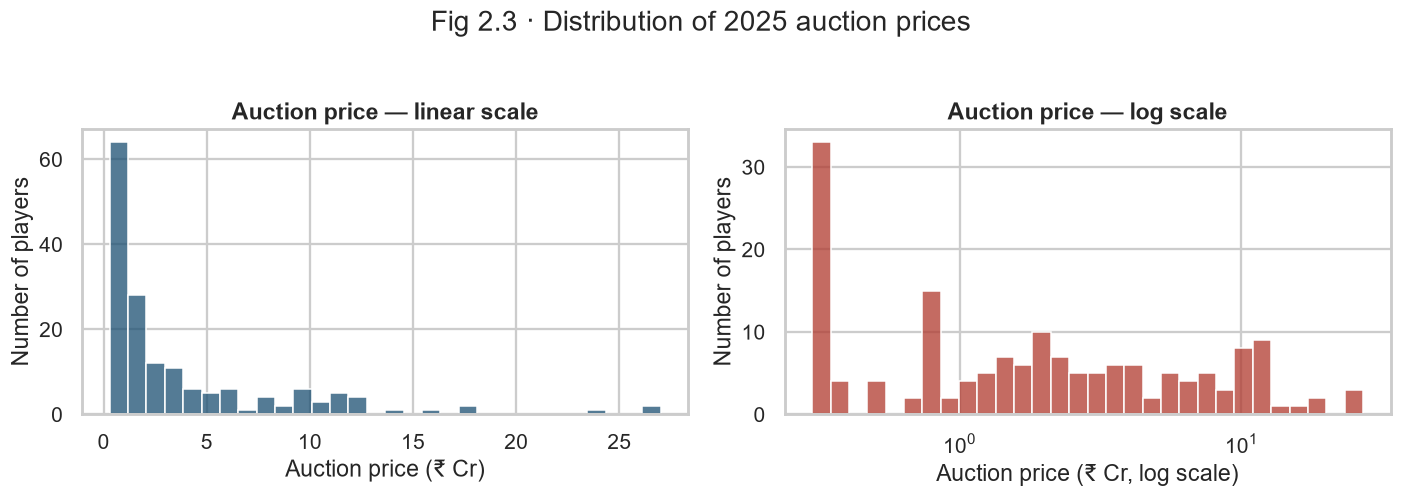

Skewness: 2.26
Median vs 90th percentile: ₹1.90 Cr  vs  ₹10.75 Cr
Top-5 players account for 18.0% of total spend


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.histplot(eda["Auction_Price_Cr"], bins=30, kde=False,
             color="#1B4F72", ax=axes[0])
axes[0].set_title("Auction price — linear scale")
axes[0].set_xlabel("Auction price (₹ Cr)")
axes[0].set_ylabel("Number of players")

sns.histplot(eda["Auction_Price_Cr"], bins=30, kde=False, log_scale=(True, False),
             color="#B03A2E", ax=axes[1])
axes[1].set_title("Auction price — log scale")
axes[1].set_xlabel("Auction price (₹ Cr, log scale)")
axes[1].set_ylabel("Number of players")

fig.suptitle("Fig 2.3 · Distribution of 2025 auction prices", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "2_3_price_distribution")
plt.show()

skew = eda["Auction_Price_Cr"].skew()
p90 = eda["Auction_Price_Cr"].quantile(0.9)
p50 = eda["Auction_Price_Cr"].median()
top5_share = eda.nlargest(5, "Auction_Price_Cr")["Auction_Price_Cr"].sum() / eda["Auction_Price_Cr"].sum()
print(f"Skewness: {skew:.2f}")
print(f"Median vs 90th percentile: ₹{p50:.2f} Cr  vs  ₹{p90:.2f} Cr")
print(f"Top-5 players account for {100*top5_share:.1f}% of total spend")


Auction spend is concentrated at the top of the price ladder — a small
number of high-value buys account for a large share of the total
outlay, which is the reason a log-price transform is used in the
clustering step.

### 2.4 Franchise spending

Total spend and mean-price-per-buy for each franchise.

In [14]:
team_stats = (
    eda.groupby("Auction_Team")
       .agg(Total_Spend_Cr=("Auction_Price_Cr", "sum"),
            Mean_Buy_Cr=("Auction_Price_Cr", "mean"),
            Players=("Player", "count"),
            Overseas_Share=("Is_Overseas", "mean"))
       .round(2)
       .sort_values("Total_Spend_Cr", ascending=False)
)
team_stats["Overseas_Share"] = (100 * team_stats["Overseas_Share"]).round(0).astype(int)
team_stats


,Total_Spend_Cr,Mean_Buy_Cr,Players,Overseas_Share
Auction_Team,,,,
Punjab Kings,108.30,5.42,20,35
Royal Challengers Bengaluru,81.95,4.55,18,44
Delhi Capitals,72.20,4.25,17,35
Gujarat Titans,68.85,3.44,20,30
Lucknow Super Giants,68.00,4.25,16,31
Chennai Super Kings,54.10,3.01,18,33
Kolkata Knight Riders,48.65,3.74,13,38
Mumbai Indians,43.90,2.93,15,47
Sunrisers Hyderabad,43.05,3.31,13,15


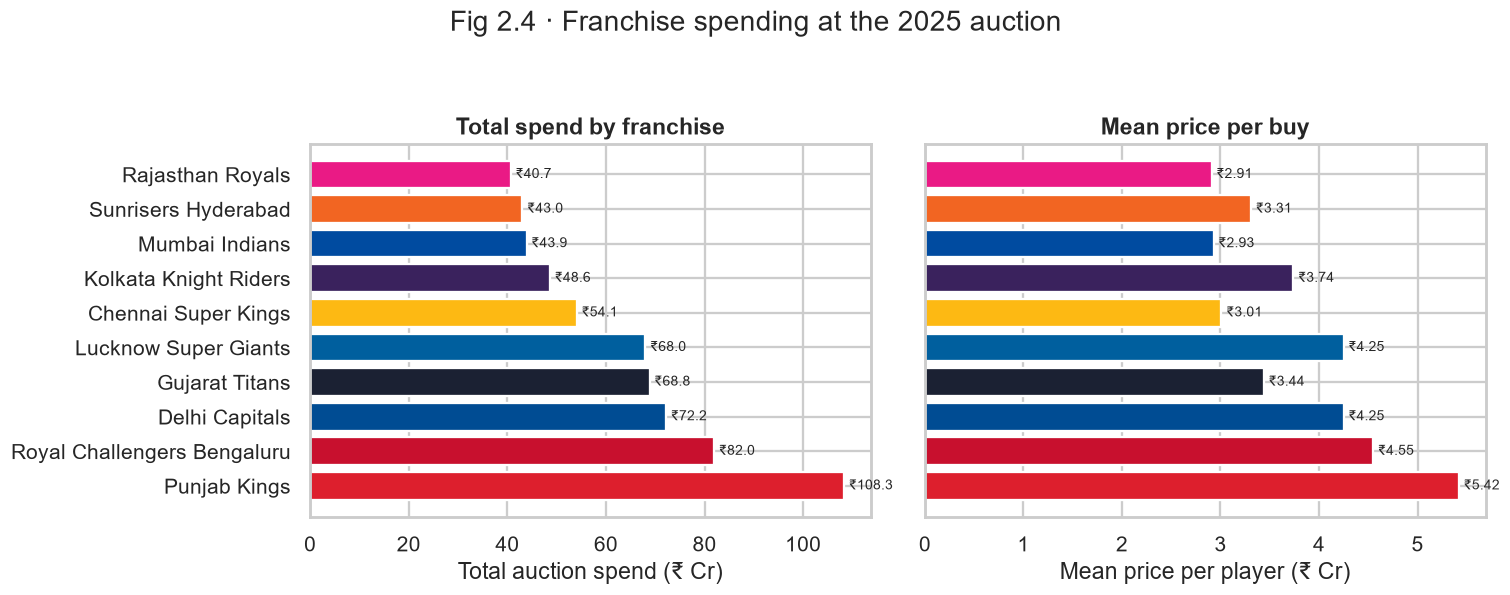

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

order = team_stats.index.tolist()
colors = [TEAM_COLORS.get(t, "#555555") for t in order]

axes[0].barh(order, team_stats["Total_Spend_Cr"], color=colors)
axes[0].invert_yaxis()
axes[0].set_title("Total spend by franchise")
axes[0].set_xlabel("Total auction spend (₹ Cr)")
for i, v in enumerate(team_stats["Total_Spend_Cr"]):
    axes[0].text(v + 1, i, f"₹{v:.1f}", va="center", fontsize=9)

axes[1].barh(order, team_stats["Mean_Buy_Cr"], color=colors)
axes[1].invert_yaxis()
axes[1].set_title("Mean price per buy")
axes[1].set_xlabel("Mean price per player (₹ Cr)")
for i, v in enumerate(team_stats["Mean_Buy_Cr"]):
    axes[1].text(v + 0.05, i, f"₹{v:.2f}", va="center", fontsize=9)

fig.suptitle("Fig 2.4 · Franchise spending at the 2025 auction", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "2_4_team_spending")
plt.show()


Franchises vary substantially in total outlay and in whether they
spread bids across many low-cost buys or concentrate spend on a few
higher-priced acquisitions.

### 2.5 Role economics

Player count by role and the auction-price distribution within each
role.

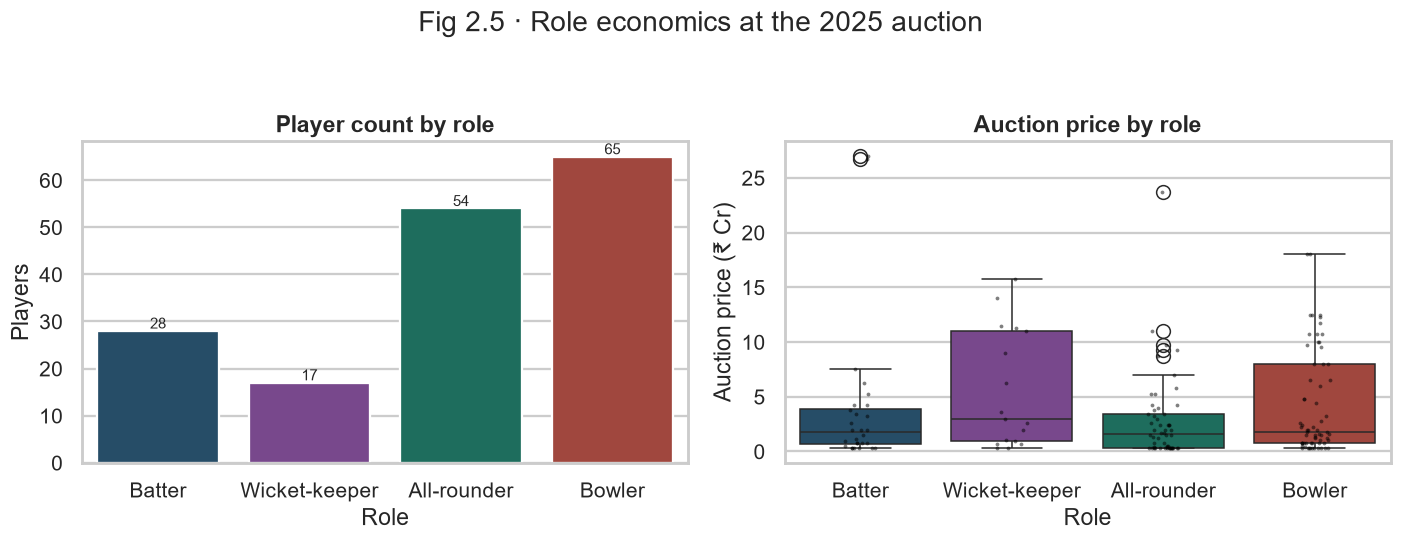

,Players,Median_Cr,Mean_Cr,Max_Cr
Role,,,,
Batter,28,1.75,3.89,27.00
Wicket-keeper,17,3.00,5.52,15.75
All-rounder,54,1.60,2.81,23.75
Bowler,65,1.80,4.23,18.00


In [51]:
role_order = ["Batter", "Wicket-keeper", "All-rounder", "Bowler"]
role_palette = {
    "Batter": "#1B4F72",
    "Wicket-keeper": "#7D3C98",
    "All-rounder": "#117A65",
    "Bowler": "#B03A2E",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=eda, x="Role", order=role_order, hue="Role",
              palette=role_palette, legend=False, ax=axes[0])
axes[0].set_title("Player count by role")
axes[0].set_ylabel("Players")
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                     ha="center", fontsize=10)

sns.boxplot(data=eda, x="Role", y="Auction_Price_Cr", order=role_order,
            hue="Role", palette=role_palette, legend=False, ax=axes[1])
sns.stripplot(data=eda, x="Role", y="Auction_Price_Cr", order=role_order,
              color="black", size=2.5, alpha=0.5, ax=axes[1])
axes[1].set_title("Auction price by role")
axes[1].set_ylabel("Auction price (₹ Cr)")

fig.suptitle("Fig 2.5 · Role economics at the 2025 auction", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "2_5_role_economics")
plt.show()

role_summary = (
    eda.groupby("Role")
       .agg(Players=("Player", "count"),
            Median_Cr=("Auction_Price_Cr", "median"),
            Mean_Cr=("Auction_Price_Cr", "mean"),
            Max_Cr=("Auction_Price_Cr", "max"))
       .round(2)
       .reindex(role_order)
)
role_summary


Roles sit on different price ladders, so the performance score in
Section 3 is role-weighted rather than a flat average.

### 2.6 Overseas premium

Price distributions split by Indian vs. overseas, and then by role
within each origin group.

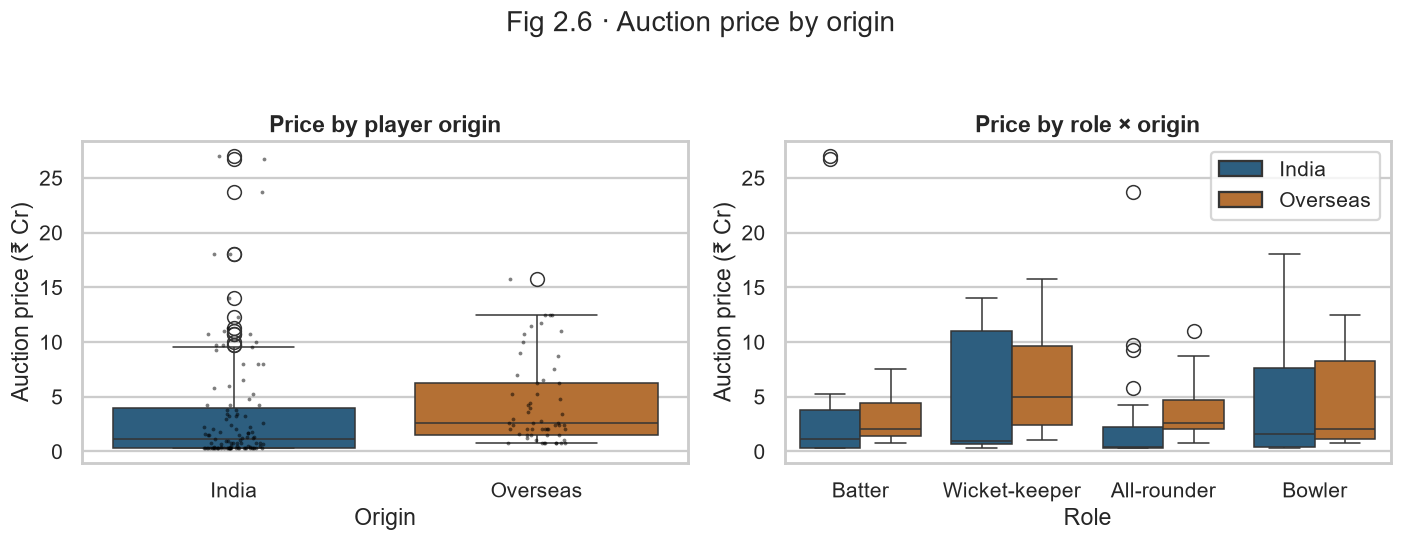

median  mean  count
Role          Origin                       
Batter        India       1.10  4.15     21
              Overseas    2.00  3.12      7
Wicket-keeper India       0.95  4.68      9
              Overseas    4.92  6.46      8
All-rounder   India       0.40  2.31     35
              Overseas    2.60  3.73     19
Bowler        India       1.55  4.03     42
              Overseas    2.00  4.61     23

In [52]:
eda["Origin"] = np.where(eda["Is_Overseas"] == 1, "Overseas", "India")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=eda, x="Origin", y="Auction_Price_Cr",
            order=["India", "Overseas"], hue="Origin",
            palette={"India": "#1F618D", "Overseas": "#CA6F1E"},
            legend=False, ax=axes[0])
sns.stripplot(data=eda, x="Origin", y="Auction_Price_Cr",
              order=["India", "Overseas"],
              color="black", size=2.5, alpha=0.5, ax=axes[0])
axes[0].set_title("Price by player origin")
axes[0].set_ylabel("Auction price (₹ Cr)")

sns.boxplot(data=eda, x="Role", y="Auction_Price_Cr", hue="Origin",
            order=role_order,
            palette={"India": "#1F618D", "Overseas": "#CA6F1E"}, ax=axes[1])
axes[1].set_title("Price by role × origin")
axes[1].set_ylabel("Auction price (₹ Cr)")
axes[1].legend(title="", loc="upper right")

fig.suptitle("Fig 2.6 · Auction price by origin", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "2_6_overseas_premium")
plt.show()

premium = (
    eda.groupby(["Role", "Origin"])["Auction_Price_Cr"]
       .agg(["median", "mean", "count"])
       .round(2)
       .reindex(role_order, level=0)
)
premium


Any gap between the India and Overseas medians within a role reflects
the IPL overseas quota — the recommendation section acknowledges this
premium when comparing candidates across origins.

### 2.7 Performance vs auction price

Scatter of career totals and per-match rates against auction price,
with linear-regression fits and Pearson correlations.

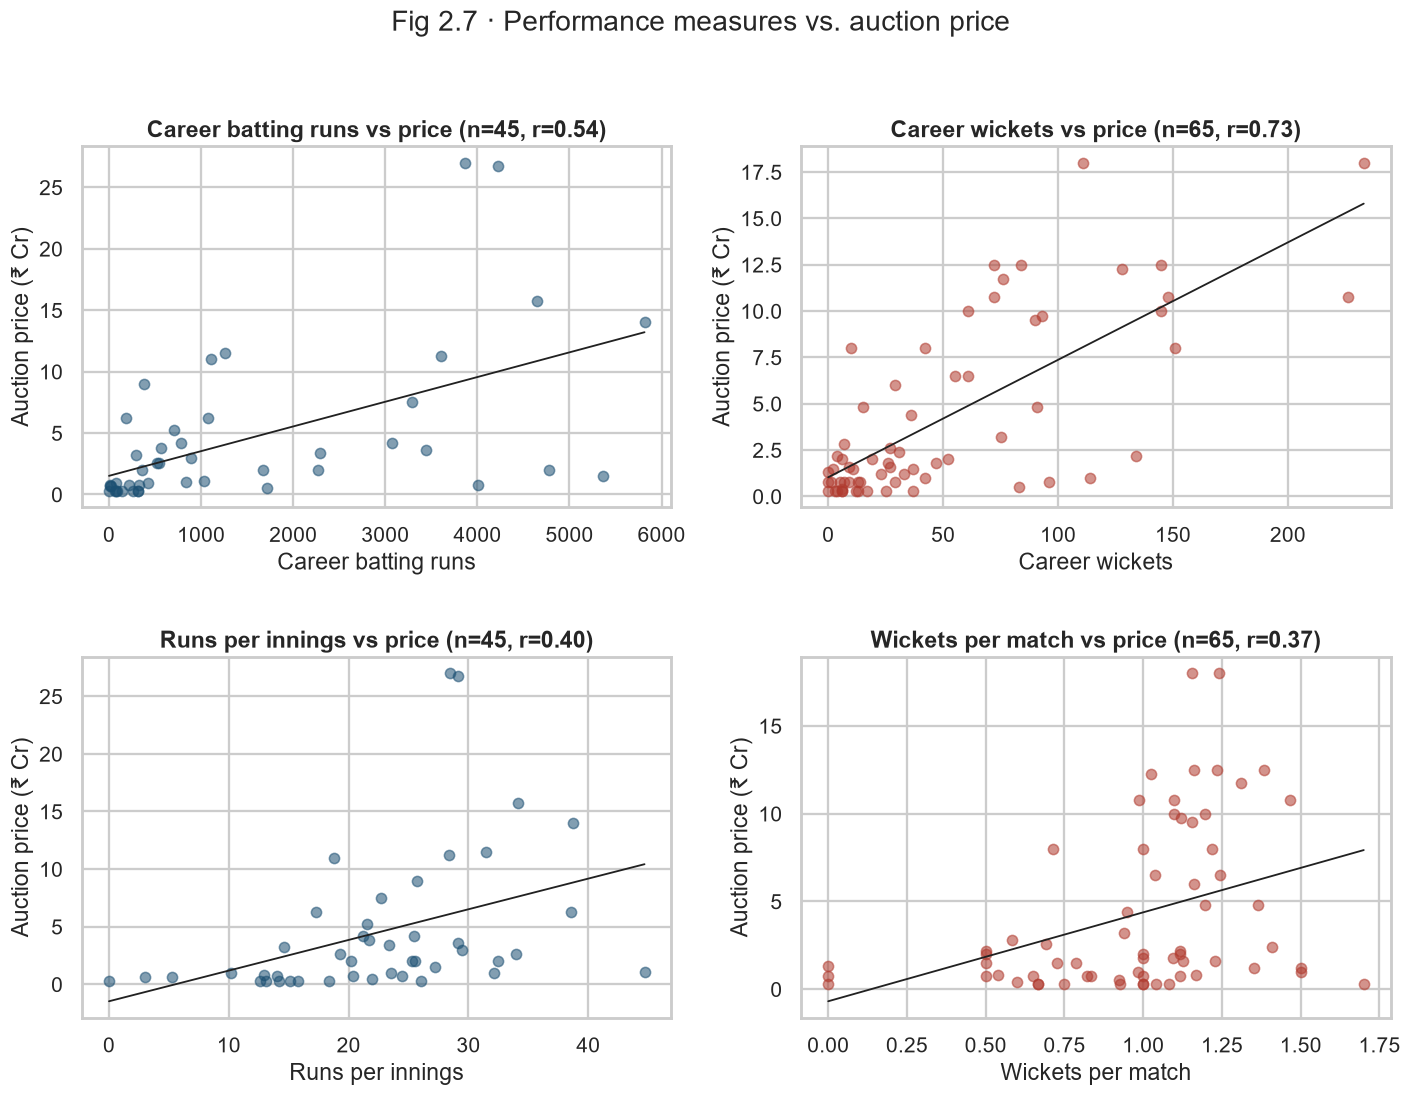

In [53]:
panels = [
    ("Bat_Runs",    "Career batting runs",      "Batter",       "Wicket-keeper"),
    ("Wkts",        "Career wickets",           "Bowler",       None),
    ("Runs_per_Inns", "Runs per innings",       "Batter",       "Wicket-keeper"),
    ("Wkts_per_Mat",  "Wickets per match",      "Bowler",       None),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (metric, label, role_a, role_b) in zip(axes.flat, panels):
    roles_keep = [r for r in [role_a, role_b] if r is not None]
    sub = eda[eda["Role"].isin(roles_keep) & eda[metric].notna()]
    sns.regplot(data=sub, x=metric, y="Auction_Price_Cr",
                scatter_kws={"alpha": 0.55, "s": 45,
                             "color": role_palette[role_a]},
                line_kws={"color": "#212121", "linewidth": 1.2},
                ci=None, ax=ax)
    corr = sub[[metric, "Auction_Price_Cr"]].corr().iloc[0, 1]
    ax.set_title(f"{label} vs price (n={len(sub)}, r={corr:.2f})")
    ax.set_xlabel(label)
    ax.set_ylabel("Auction price (₹ Cr)")

fig.suptitle("Fig 2.7 · Performance measures vs. auction price", y=1.00)
fig.tight_layout(rect=(0, 0, 1, 0.97), h_pad=2.4)
save_fig(fig, "2_7_performance_vs_price")
plt.show()


Career totals correlate with price more strongly than per-match rates
— evidence that the market weighs career résumés above current
efficiency.

### 2.8 Career volume vs form

Matches played (a proxy for career reputation) and boundary rate
(a proxy for current form) plotted against auction price.

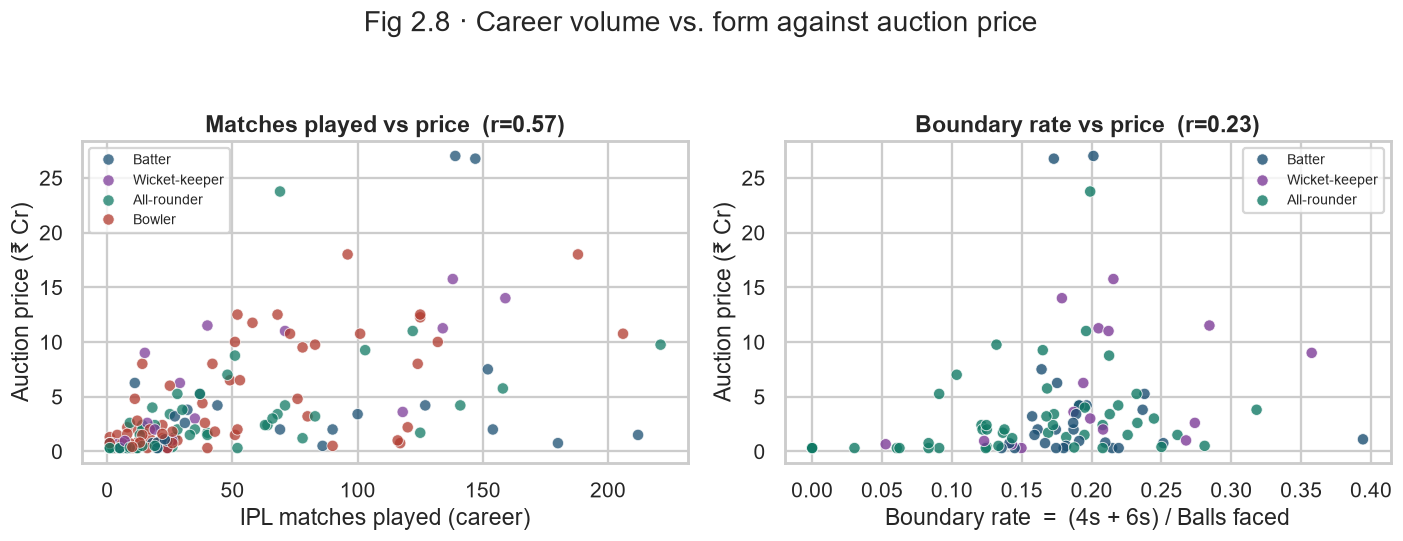

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=eda, x="Mat", y="Auction_Price_Cr", hue="Role",
                hue_order=role_order, palette=role_palette,
                s=55, alpha=0.75, ax=axes[0])
axes[0].set_title(f"Matches played vs price  (r={eda['Mat'].corr(eda['Auction_Price_Cr']):.2f})")
axes[0].set_xlabel("IPL matches played (career)")
axes[0].set_ylabel("Auction price (₹ Cr)")
axes[0].legend(title="", loc="upper left", fontsize=9)

bat_view = eda[eda["Role"].isin(["Batter", "Wicket-keeper", "All-rounder"])
               & eda["Boundary_Rate"].notna()]
sns.scatterplot(data=bat_view, x="Boundary_Rate", y="Auction_Price_Cr",
                hue="Role", hue_order=["Batter", "Wicket-keeper", "All-rounder"],
                palette=role_palette, s=55, alpha=0.8, ax=axes[1])
axes[1].set_title(f"Boundary rate vs price  (r={bat_view['Boundary_Rate'].corr(bat_view['Auction_Price_Cr']):.2f})")
axes[1].set_xlabel("Boundary rate  =  (4s + 6s) / Balls faced")
axes[1].set_ylabel("Auction price (₹ Cr)")
axes[1].legend(title="", loc="upper right", fontsize=9)

fig.suptitle("Fig 2.8 · Career volume vs. form against auction price", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "2_8_reputation_vs_form")
plt.show()


The stronger correlation of career matches with price, relative to
boundary rate, reinforces the same reputation-over-form pattern.

### 2.9 Auction price vs base price

Distribution of the auction-to-base multiplier and the top-10 highest
multipliers.

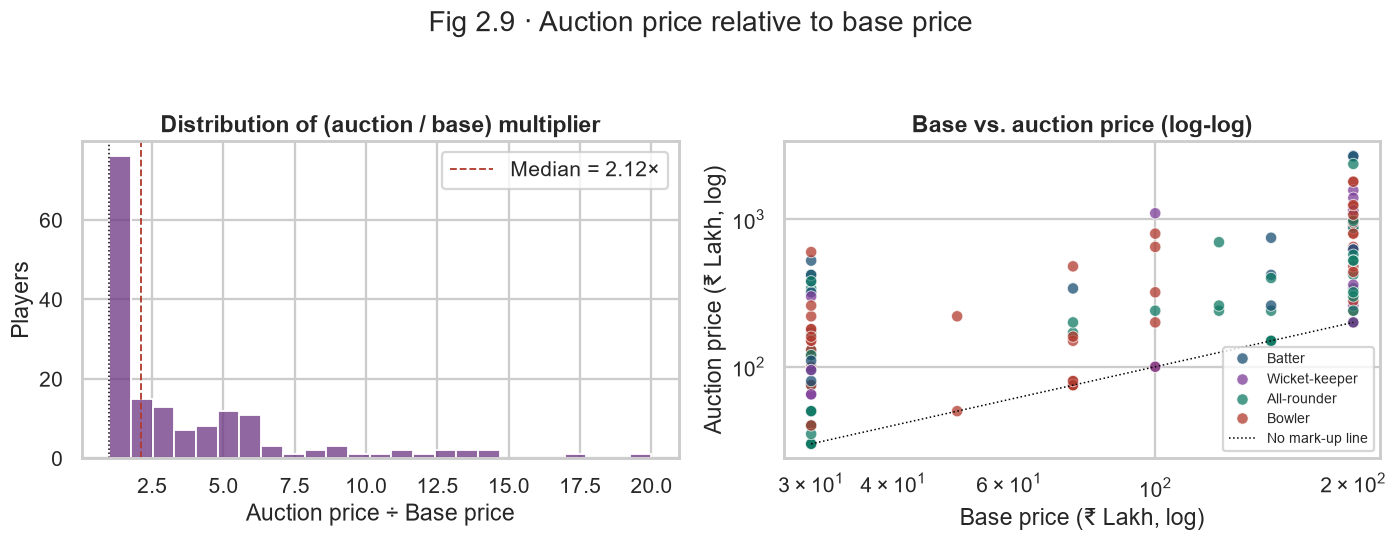


Top 10 bid wars (highest auction ÷ base multiplier):


,Player,Role,Country,Auction_Team,Base_Price_Lakh,Auction_Price_Lakh,Multiplier
0,Rasikh Salam,Bowler,India,Royal Challengers Bengaluru,30,600,20.00
1,Naman Dhir,Batter,India,Mumbai Indians,30,525,17.50
2,Abdul Samad,All-rounder,India,Lucknow Super Giants,30,420,14.00
3,N Wadhera,Batter,India,Punjab Kings,30,420,14.00
4,RR Pant,Batter,India,Lucknow Super Giants,200,2700,13.50
5,SS Iyer,Batter,India,Punjab Kings,200,2675,13.38
6,P Arya,All-rounder,India,Punjab Kings,30,380,12.67
7,AR Sharma,Batter,India,Delhi Capitals,30,380,12.67
8,VR Iyer,All-rounder,India,Kolkata Knight Riders,200,2375,11.88
9,A Kamboj,All-rounder,India,Chennai Super Kings,30,340,11.33


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(eda["Price_Multiplier"], bins=25, color="#6C3483", ax=axes[0])
axes[0].axvline(1, color="black", linestyle=":", linewidth=1)
axes[0].axvline(eda["Price_Multiplier"].median(), color="#B03A2E",
                linestyle="--", linewidth=1.2,
                label=f"Median = {eda['Price_Multiplier'].median():.2f}×")
axes[0].set_title("Distribution of (auction / base) multiplier")
axes[0].set_xlabel("Auction price ÷ Base price")
axes[0].set_ylabel("Players")
axes[0].legend()

sns.scatterplot(data=eda, x="Base_Price_Lakh", y="Auction_Price_Lakh",
                hue="Role", hue_order=role_order, palette=role_palette,
                s=55, alpha=0.75, ax=axes[1])
diag = np.linspace(eda["Base_Price_Lakh"].min(), eda["Base_Price_Lakh"].max(), 50)
axes[1].plot(diag, diag, color="black", linestyle=":",
             linewidth=1, label="No mark-up line")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Base vs. auction price (log-log)")
axes[1].set_xlabel("Base price (₹ Lakh, log)")
axes[1].set_ylabel("Auction price (₹ Lakh, log)")
axes[1].legend(title="", loc="lower right", fontsize=9)

fig.suptitle("Fig 2.9 · Auction price relative to base price", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "2_9_base_vs_auction")
plt.show()

print("\nTop 10 bid wars (highest auction ÷ base multiplier):")
biggest_markups = (
    eda.assign(Multiplier=eda["Price_Multiplier"].round(2))
       .sort_values("Multiplier", ascending=False)
       .head(10)
       [["Player", "Role", "Country", "Auction_Team",
         "Base_Price_Lakh", "Auction_Price_Lakh", "Multiplier"]]
       .reset_index(drop=True)
)
biggest_markups


The upper tail of the multiplier distribution identifies the players
whose auction price was many times their base — the acquisitions most
likely to attract value scrutiny.

### 2.10 Correlation heatmap

Pairwise Pearson correlations across price and performance features.

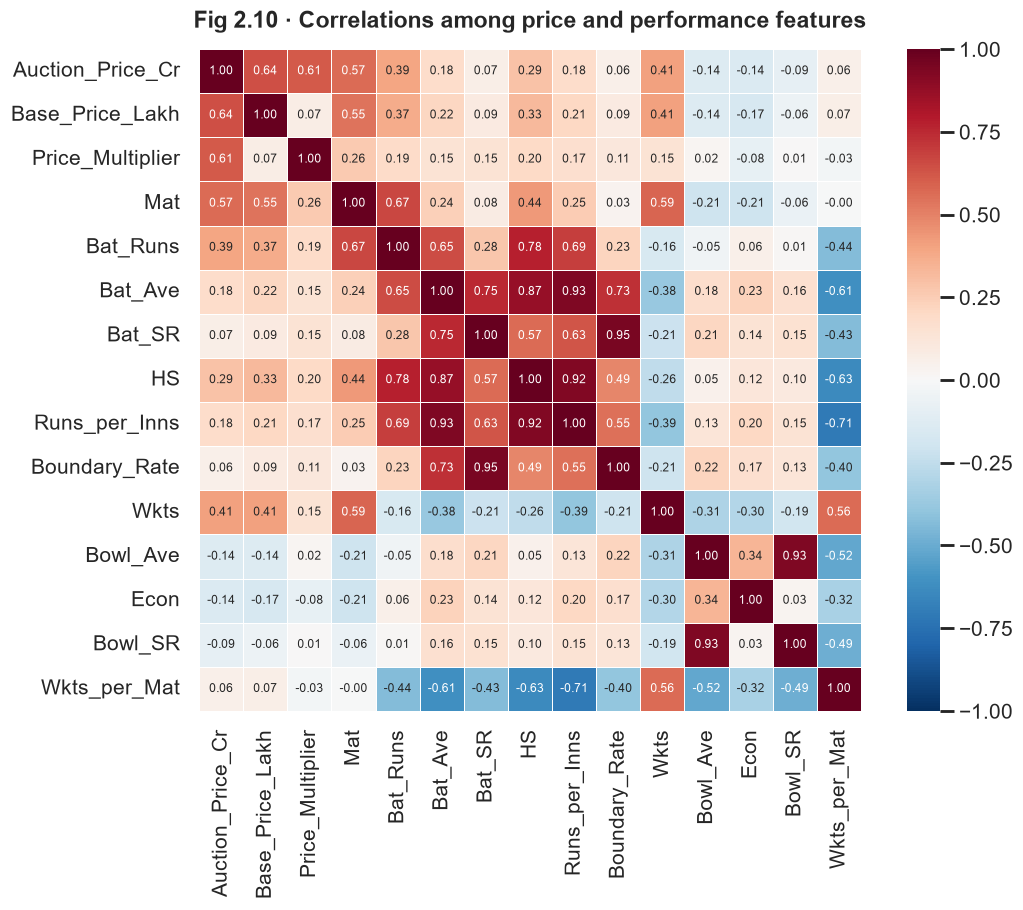

Top drivers of Auction_Price_Cr (by absolute correlation):


,r
Base_Price_Lakh,0.64
Price_Multiplier,0.61
Mat,0.57
Wkts,0.41
Bat_Runs,0.39
HS,0.29
Runs_per_Inns,0.18
Bat_Ave,0.18


In [56]:
corr_cols = [
    "Auction_Price_Cr", "Base_Price_Lakh", "Price_Multiplier",
    "Mat", "Bat_Runs", "Bat_Ave", "Bat_SR", "HS",
    "Runs_per_Inns", "Boundary_Rate",
    "Wkts", "Bowl_Ave", "Econ", "Bowl_SR", "Wkts_per_Mat",
]
corr_mat = eda[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10.5, 8.5))
sns.heatmap(corr_mat, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            square=True, linewidths=0.4, ax=ax)
ax.set_title("Fig 2.10 · Correlations among price and performance features", pad=14)
fig.tight_layout()
save_fig(fig, "2_10_correlation_heatmap")
plt.show()

print("Top drivers of Auction_Price_Cr (by absolute correlation):")
price_corr = corr_mat["Auction_Price_Cr"].drop("Auction_Price_Cr")
price_corr.reindex(price_corr.abs().sort_values(ascending=False).index).round(2).head(8).to_frame("r")


## 3. Performance score and tiers

Constructs a role-weighted performance score for every player and
splits it into Low / Medium / High tiers used as the classification
target in Section 4 and as the vertical axis of the clustering in
Section 5.

**Score construction:**

* Batting sub-score — weighted z-scores of `Bat_Runs (0.30)`,
  `Runs_per_Inns (0.25)`, `Bat_SR (0.20)`, `Boundary_Rate (0.15)` and
  `50s + 100s (0.10)`.
* Bowling sub-score — weighted z-scores of `Wkts (0.30)`,
  `Wkts_per_Mat (0.25)`, `Econ (inverted, 0.20)`, `Bowl_Ave (inverted,
  0.15)` and `4W + 5W (0.10)`.
* Missing feature weights are renormalised at the row level.

**Role blend for the overall score:**

| Role | Batting weight | Bowling weight |
|---|---:|---:|
| Batter | 0.90 | 0.10 |
| Wicket-keeper | 0.90 | 0.10 |
| All-rounder | 0.55 | 0.45 |
| Bowler | 0.15 | 0.85 |

Players with only one discipline recorded default to 100% of that
sub-score.

### 3.1 Batting and bowling sub-scores

In [24]:
scored = eda.copy()

# 50s + 100s and 4W + 5W as milestone-innings features
scored["Impact_Innings"] = scored["50"] + scored["100"]
scored["Haul_Innings"]   = scored["4W"] + scored["5W"]

BAT_WEIGHTS = {
    "Bat_Runs":       0.30,
    "Runs_per_Inns":  0.25,
    "Bat_SR":         0.20,
    "Boundary_Rate":  0.15,
    "Impact_Innings": 0.10,
}
BOWL_WEIGHTS = {
    "Wkts":         0.30,
    "Wkts_per_Mat": 0.25,
    "Econ":         0.20,   # inverted below
    "Bowl_Ave":     0.15,   # inverted below
    "Haul_Innings": 0.10,
}
INVERT_BOWL = {"Econ", "Bowl_Ave"}


def zscore_within(series: pd.Series, mask: pd.Series) -> pd.Series:
    """Z-score a column across the eligible sub-population only."""
    eligible = series.where(mask)
    mu, sigma = eligible.mean(), eligible.std(ddof=0)
    if sigma == 0 or np.isnan(sigma):
        return pd.Series(0.0, index=series.index)
    return (eligible - mu) / sigma


def weighted_zscore(df: pd.DataFrame, weights: dict[str, float],
                    invert: set[str], mask: pd.Series) -> pd.Series:
    """Weighted average of z-scores with weight renormalisation per row."""
    z_frame = pd.DataFrame(index=df.index)
    for feat, w in weights.items():
        z = zscore_within(df[feat], mask)
        if feat in invert:
            z = -z
        z_frame[feat] = z * w

    w_series = pd.Series(weights, dtype=float)
    weight_matrix = pd.DataFrame(
        np.where(z_frame.notna(), w_series.values, 0.0),
        index=df.index, columns=weights.keys(),
    )
    numerator   = z_frame.sum(axis=1, min_count=1)
    denominator = weight_matrix.sum(axis=1)
    result = numerator / denominator.replace(0, np.nan)
    return result.where(mask)


bat_mask  = scored["Has_Batting"]
bowl_mask = scored["Has_Bowling"]

scored["Batting_Score"] = weighted_zscore(
    scored, BAT_WEIGHTS, set(), bat_mask
)
scored["Bowling_Score"] = weighted_zscore(
    scored, BOWL_WEIGHTS, INVERT_BOWL, bowl_mask
)

sub_summary = pd.DataFrame({
    "Batters_scored":  [int(scored["Batting_Score"].notna().sum())],
    "Bowlers_scored":  [int(scored["Bowling_Score"].notna().sum())],
    "Bat_score_mean":  [scored["Batting_Score"].mean()],
    "Bat_score_std":   [scored["Batting_Score"].std()],
    "Bowl_score_mean": [scored["Bowling_Score"].mean()],
    "Bowl_score_std":  [scored["Bowling_Score"].std()],
}).round(3).T.rename(columns={0: "value"})
print(sub_summary.to_string())


                   value
Batters_scored   148.000
Bowlers_scored   128.000
Bat_score_mean     0.000
Bat_score_std      0.810
Bowl_score_mean   -0.020
Bowl_score_std     0.755


### 3.2 Overall score with role blend

In [25]:
ROLE_BLEND = {
    "Batter":        (0.90, 0.10),
    "Wicket-keeper": (0.90, 0.10),
    "All-rounder":   (0.55, 0.45),
    "Bowler":        (0.15, 0.85),
}

def role_blended_score(row):
    w_bat, w_bowl = ROLE_BLEND.get(row["Role"], (0.5, 0.5))
    b, o = row["Batting_Score"], row["Bowling_Score"]
    if pd.isna(b) and pd.isna(o):
        return np.nan
    if pd.isna(b):
        return o
    if pd.isna(o):
        return b
    return w_bat * b + w_bowl * o

scored["Overall_Score"] = scored.apply(role_blended_score, axis=1)

print("Overall_Score distribution:")
print(scored["Overall_Score"].describe().round(3).to_string())
print("\nCount by role:")
print(
    scored.groupby("Role")["Overall_Score"]
          .agg(["count", "mean", "std", "min", "max"])
          .round(3)
          .reindex(role_order)
          .to_string()
)


Overall_Score distribution:
count    164.000
mean       0.202
std        0.700
min       -2.254
25%       -0.242
50%        0.126
75%        0.561
max        2.665

Count by role:
               count   mean    std    min    max
Role                                            
Batter            28  0.626  0.655 -0.132  1.818
Wicket-keeper     17  0.659  1.003 -1.168  2.665
All-rounder       54 -0.123  0.513 -2.254  0.996
Bowler            65  0.169  0.611 -1.086  1.886


### 3.3 Performance tiers

Overall score is split into three tiers (Low / Medium / High) using a
tertile cut. The resulting classes are approximately balanced, which
avoids class-imbalance handling in the classifier.

In [26]:
tier_labels = ["Low", "Medium", "High"]
q_low, q_high = np.quantile(scored["Overall_Score"].dropna(), [1/3, 2/3])
print(f"Tertile cut-offs: Low <= {q_low:.3f}  <  Medium  <=  {q_high:.3f}  <  High")

scored["Performance_Tier"] = pd.cut(
    scored["Overall_Score"],
    bins=[-np.inf, q_low, q_high, np.inf],
    labels=tier_labels,
)

print("\nTier counts:")
print(scored["Performance_Tier"].value_counts().reindex(tier_labels).to_string())

print("\nTier × Role composition:")
print(
    pd.crosstab(scored["Performance_Tier"], scored["Role"])
      .reindex(tier_labels)
      [role_order]
      .to_string()
)


Tertile cut-offs: Low <= -0.090  <  Medium  <=  0.368  <  High

Tier counts:
Performance_Tier
Low       55
Medium    54
High      55

Tier × Role composition:
Role              Batter  Wicket-keeper  All-rounder  Bowler
Performance_Tier                                            
Low                    4              4           27      20
Medium                 9              2           21      22
High                  15             11            6      23


### 3.4 Score distribution and tier composition

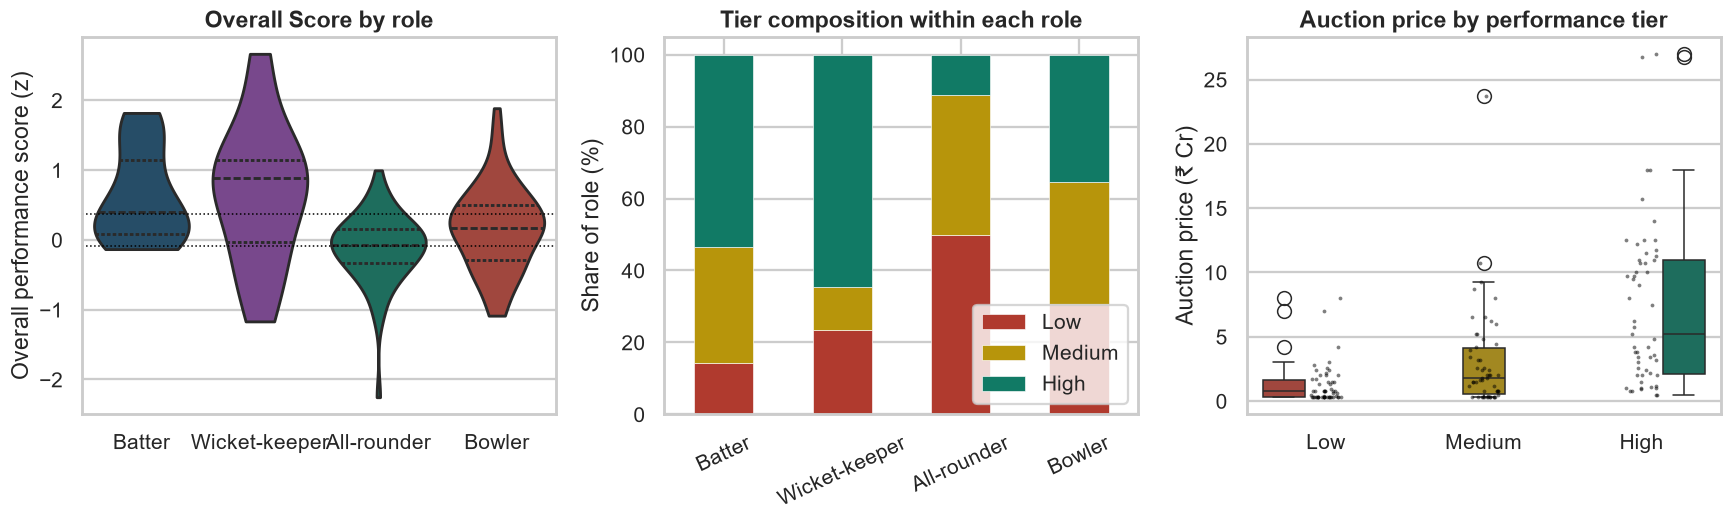

In [57]:
tier_palette = {"Low": "#B03A2E", "Medium": "#B7950B", "High": "#117A65"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.violinplot(data=scored, x="Role", y="Overall_Score", order=role_order,
               hue="Role", palette=role_palette, legend=False,
               inner="quartile", cut=0, ax=axes[0])
axes[0].axhline(q_low, color="black", linestyle=":", linewidth=1)
axes[0].axhline(q_high, color="black", linestyle=":", linewidth=1)
axes[0].set_title("Overall Score by role")
axes[0].set_ylabel("Overall performance score (z)")
axes[0].set_xlabel("")

tier_by_role = (
    pd.crosstab(scored["Role"], scored["Performance_Tier"], normalize="index")
      .reindex(role_order)
      [tier_labels] * 100
)
tier_by_role.plot(kind="bar", stacked=True, ax=axes[1],
                  color=[tier_palette[t] for t in tier_labels],
                  edgecolor="white", linewidth=0.4)
axes[1].set_title("Tier composition within each role")
axes[1].set_ylabel("Share of role (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="", loc="lower right")

sns.boxplot(data=scored, x="Performance_Tier", y="Auction_Price_Cr",
            order=tier_labels, hue="Performance_Tier",
            palette=tier_palette, legend=False, ax=axes[2])
sns.stripplot(data=scored, x="Performance_Tier", y="Auction_Price_Cr",
              order=tier_labels, color="black", size=2.5, alpha=0.5, ax=axes[2])
axes[2].set_title("Auction price by performance tier")
axes[2].set_ylabel("Auction price (₹ Cr)")
axes[2].set_xlabel("")

fig.tight_layout()
save_fig(fig, "3_4_performance_score_tiers")
plt.show()


### 3.5 Top players by score

Top overall, top batting-score and top bowling-score players. Used to
verify the score is well-calibrated by inspection.

In [28]:
display_cols = ["Player", "Role", "Country", "Mat",
                "Overall_Score", "Performance_Tier",
                "Auction_Price_Cr"]

print("Top 10 by Overall Score:")
top_overall = (
    scored.sort_values("Overall_Score", ascending=False)
          .head(10)[display_cols]
          .round({"Overall_Score": 2, "Auction_Price_Cr": 2})
          .reset_index(drop=True)
)
display(top_overall)

print("\nTop 5 by Batting Score (non-null only):")
top_bat = (
    scored.dropna(subset=["Batting_Score"])
          .sort_values("Batting_Score", ascending=False)
          .head(5)[["Player", "Role", "Mat", "Bat_Runs",
                     "Runs_per_Inns", "Batting_Score", "Auction_Price_Cr"]]
          .round(2)
          .reset_index(drop=True)
)
display(top_bat)

print("\nTop 5 by Bowling Score (non-null only):")
top_bowl = (
    scored.dropna(subset=["Bowling_Score"])
          .sort_values("Bowling_Score", ascending=False)
          .head(5)[["Player", "Role", "Mat", "Wkts",
                     "Econ", "Bowling_Score", "Auction_Price_Cr"]]
          .round(2)
          .reset_index(drop=True)
)
display(top_bowl)


Top 10 by Overall Score:


,Player,Role,Country,Mat,Overall_Score,Performance_Tier,Auction_Price_Cr
0,KL Rahul,Wicket-keeper,India,159,2.66,High,14.00
1,JC Buttler,Wicket-keeper,England,138,2.16,High,15.75
2,YS Chahal,Bowler,India,188,1.89,High,18.00
3,AM Rahane,Batter,India,212,1.82,High,1.50
4,F du Plessis,Batter,South Africa,154,1.75,High,2.00
5,V Sooryavanshi,Batter,India,23,1.73,High,1.10
6,RR Pant,Batter,India,139,1.63,High,27.00
7,B Kumar,Bowler,India,206,1.60,High,10.75
8,SS Iyer,Batter,India,147,1.56,High,26.75
9,Q de Kock,Wicket-keeper,South Africa,118,1.53,High,3.60



Top 5 by Batting Score (non-null only):


,Player,Role,Mat,Bat_Runs,Runs_per_Inns,Batting_Score,Auction_Price_Cr
0,KL Rahul,Wicket-keeper,159,5815,38.77,2.66,14.00
1,JC Buttler,Wicket-keeper,138,4646,34.16,2.16,15.75
2,F du Plessis,Batter,154,4773,32.47,2.08,2.00
3,AM Rahane,Batter,212,5367,27.24,2.03,1.50
4,KT Maphaka,Bowler,4,8,8.00,1.98,1.50



Top 5 by Bowling Score (non-null only):


,Player,Role,Mat,Wkts,Econ,Bowling_Score,Auction_Price_Cr
0,YS Chahal,Bowler,188,233,8.05,2.39,18.00
1,B Kumar,Bowler,206,226,7.71,1.97,10.75
2,K Rabada,Bowler,101,148,8.79,1.70,10.75
3,HV Patel,Bowler,124,151,8.92,1.49,8.00
4,R Ashwin,All-rounder,221,187,7.20,1.29,9.75


### 3.6 Save the scored dataset

Written to `data/processed/ipl_player_scored.csv`.

In [29]:
scored_path = PROCESSED_DIR / "ipl_player_scored.csv"
scored.to_csv(scored_path, index=False)

print(f"Saved: {scored_path.relative_to(PROJECT_ROOT)}")
print(f"Shape: {scored.shape}")
print(f"New columns added in Phase 3:")
for c in ["Impact_Innings", "Haul_Innings",
          "Batting_Score", "Bowling_Score",
          "Overall_Score", "Performance_Tier"]:
    print(f"  - {c}")


Saved: data\processed\ipl_player_scored.csv
Shape: (164, 50)
New columns added in Phase 3:
  - Impact_Innings
  - Haul_Innings
  - Batting_Score
  - Bowling_Score
  - Overall_Score
  - Performance_Tier


## 4. Classification

Supervised classification of the Low / Medium / High performance tier
using two standard business-analytics models. The classifier verifies
that the tier is recoverable from raw stats and surfaces the features
that drive tier assignment.

* **Features:** raw and derived performance statistics, one-hot
  `Role`, `Is_Overseas`. Score and price columns are excluded to
  prevent trivial leakage.
* **Target:** `Performance_Tier` treated as a three-class nominal
  label.
* **Evaluation:** 5-fold stratified cross-validation for point
  estimates and a stratified 80/20 holdout for a single confusion
  matrix.

### 4.1 Feature matrix and holdout split

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df = pd.read_csv(PROCESSED_DIR / "ipl_player_scored.csv")

NUMERIC_FEATURES = [
    "Mat",
    "Bat_Runs", "Bat_Ave", "Bat_SR", "HS",
    "Runs_per_Inns", "Boundary_Rate", "Impact_Innings",
    "Wkts", "Bowl_Ave", "Econ", "Bowl_SR",
    "Wkts_per_Mat", "Haul_Innings", "Bowling_Contribution",
]
BINARY_FEATURES = ["Has_Batting", "Has_Bowling", "Is_Overseas"]
CATEGORICAL_FEATURES = ["Role"]
ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

X = model_df[ALL_FEATURES].copy()
X[BINARY_FEATURES] = X[BINARY_FEATURES].astype(int)
y = model_df["Performance_Tier"].astype("string")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

print(f"Total    : {len(X)}  features={X.shape[1]}")
print(f"Train    : {len(X_train)}   Test: {len(X_test)}")
print("Class balance:")
print(y.value_counts().reindex(tier_labels).to_string())
print("\nTrain class balance:")
print(y_train.value_counts().reindex(tier_labels).to_string())
print("\nTest class balance:")
print(y_test.value_counts().reindex(tier_labels).to_string())


Total    : 164  features=19
Train    : 131   Test: 33
Class balance:
Performance_Tier
Low       55
Medium    54
High      55

Train class balance:
Performance_Tier
Low       44
Medium    43
High      44

Test class balance:
Performance_Tier
Low       11
Medium    11
High      11


### 4.2 Logistic Regression and Random Forest

Both models are wrapped in a `Pipeline` so that median-imputation,
scaling and one-hot encoding are fit strictly on training data inside
each CV fold. Logistic Regression provides an interpretable baseline;
Random Forest provides a non-linear comparison.

In [32]:
numeric_transformer = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
binary_transformer = SimpleImputer(strategy="most_frequent")
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor_lr = ColumnTransformer([
    ("num", numeric_transformer,     NUMERIC_FEATURES),
    ("bin", binary_transformer,      BINARY_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])
preprocessor_rf = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
    ("bin", SimpleImputer(strategy="most_frequent"), BINARY_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_FEATURES),
])

lr_model = Pipeline([
    ("preprocess", preprocessor_lr),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        C=1.0,
        random_state=42,
    )),
])

rf_model = Pipeline([
    ("preprocess", preprocessor_rf),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate(model, name):
    acc_cv = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    f1_cv  = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Model": name,
        "CV accuracy":    f"{acc_cv.mean():.3f} ± {acc_cv.std():.3f}",
        "CV macro F1":    f"{f1_cv.mean():.3f} ± {f1_cv.std():.3f}",
        "Holdout accuracy": accuracy_score(y_test, y_pred),
        "Holdout macro F1": f1_score(y_test, y_pred, average="macro"),
        "_y_pred": y_pred,
        "_cv_acc": acc_cv,
    }


results_lr = evaluate(lr_model, "Logistic Regression")
results_rf = evaluate(rf_model, "Random Forest")
print("Trained both models. CV done, holdout predictions ready.")


Trained both models. CV done, holdout predictions ready.


### 4.3 Comparison metrics

In [33]:
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in (results_lr, results_rf)
])
comparison["Holdout accuracy"] = comparison["Holdout accuracy"].round(3)
comparison["Holdout macro F1"] = comparison["Holdout macro F1"].round(3)
print("Model comparison:")
display(comparison)

print("\nPer-class holdout metrics — Logistic Regression:")
print(classification_report(y_test, results_lr["_y_pred"],
                            labels=tier_labels, zero_division=0))

print("\nPer-class holdout metrics — Random Forest:")
print(classification_report(y_test, results_rf["_y_pred"],
                            labels=tier_labels, zero_division=0))


Model comparison:


,Model,CV accuracy,CV macro F1,Holdout accuracy,Holdout macro F1
0,Logistic Regression,0.805 ± 0.059,0.803 ± 0.058,0.758,0.758
1,Random Forest,0.836 ± 0.048,0.832 ± 0.054,0.788,0.787



Per-class holdout metrics — Logistic Regression:
              precision    recall  f1-score   support

         Low       0.69      0.82      0.75        11
      Medium       0.70      0.64      0.67        11
        High       0.90      0.82      0.86        11

    accuracy                           0.76        33
   macro avg       0.76      0.76      0.76        33
weighted avg       0.76      0.76      0.76        33


Per-class holdout metrics — Random Forest:
              precision    recall  f1-score   support

         Low       0.70      0.64      0.67        11
      Medium       0.67      0.73      0.70        11
        High       1.00      1.00      1.00        11

    accuracy                           0.79        33
   macro avg       0.79      0.79      0.79        33
weighted avg       0.79      0.79      0.79        33



### 4.4 Confusion matrices

Rows are the true tier, columns the predicted tier. Adjacent-tier
confusions (Low ↔ Medium, Medium ↔ High) are unavoidable near the
tertile boundaries; Low ↔ High confusions would indicate a genuine
disagreement with the score definition.

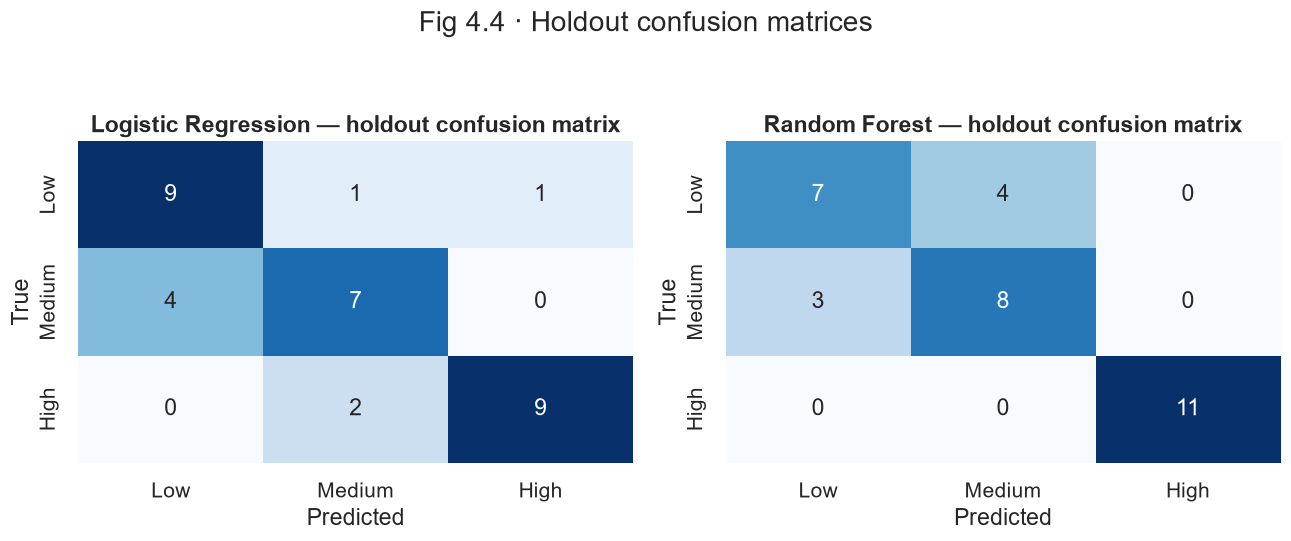

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, results, label in zip(
    axes,
    [results_lr, results_rf],
    ["Logistic Regression", "Random Forest"],
):
    cm = confusion_matrix(y_test, results["_y_pred"], labels=tier_labels)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=tier_labels, yticklabels=tier_labels, ax=ax,
    )
    ax.set_title(f"{label} — holdout confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig.suptitle("Fig 4.4 · Holdout confusion matrices", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "4_4_confusion_matrices")
plt.show()


### 4.5 Feature importance

Mean absolute Logistic Regression coefficient across classes and
Random Forest Gini importance. Agreement between the two rankings
signals a robust set of tier-driving features.

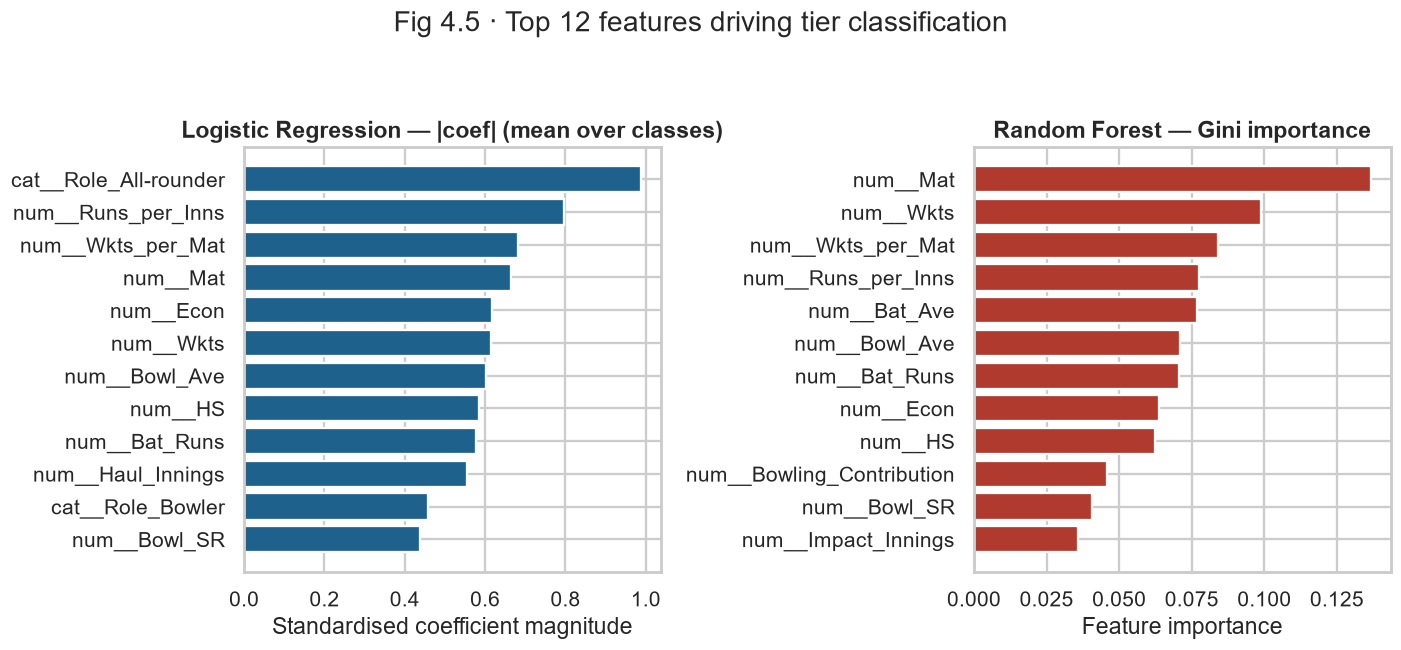

In [59]:
lr_pipe = results_lr  # already fitted on the training set above
lr_fitted_pre = lr_model.named_steps["preprocess"]
rf_fitted_pre = rf_model.named_steps["preprocess"]

feature_names = lr_fitted_pre.get_feature_names_out()

lr_coefs = np.abs(lr_model.named_steps["clf"].coef_).mean(axis=0)
lr_imp = (
    pd.Series(lr_coefs, index=feature_names)
      .sort_values(ascending=False)
      .head(12)
      .iloc[::-1]
)

rf_imp = (
    pd.Series(
        rf_model.named_steps["clf"].feature_importances_,
        index=rf_fitted_pre.get_feature_names_out(),
    )
    .sort_values(ascending=False)
    .head(12)
    .iloc[::-1]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(lr_imp.index, lr_imp.values, color="#1F618D")
axes[0].set_title("Logistic Regression — |coef| (mean over classes)")
axes[0].set_xlabel("Standardised coefficient magnitude")

axes[1].barh(rf_imp.index, rf_imp.values, color="#B03A2E")
axes[1].set_title("Random Forest — Gini importance")
axes[1].set_xlabel("Feature importance")

fig.suptitle("Fig 4.5 · Top 12 features driving tier classification", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "4_5_feature_importance")
plt.show()


## 5. K-Means value clustering

Combines the Section 3 performance score with the auction price to
identify value-efficiency groups.

* **Algorithm:** K-Means, `n_init=10`, `random_state=42`.
* **Inputs:** standardised `Overall_Score` and standardised
  `log(Auction_Price_Lakh)`.
* **Number of clusters:** `k = 4`, chosen from the elbow and
  silhouette diagnostics below and aligned with the four intended
  value quadrants.
* **Labels:** assigned only after inspecting the centroids and
  representative players of each cluster.

### 5.1 Prepare the 2-D input

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

value_df = pd.read_csv(PROCESSED_DIR / "ipl_player_scored.csv")

cluster_input = value_df[["Overall_Score", "log_Auction_Price"]].copy()
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(cluster_input.values)

print("Cluster input shape:", X_cluster.shape)
print(f"Overall_Score       (z): mean={X_cluster[:, 0].mean():+.3f}  std={X_cluster[:, 0].std():.3f}")
print(f"log_Auction_Price   (z): mean={X_cluster[:, 1].mean():+.3f}  std={X_cluster[:, 1].std():.3f}")


Cluster input shape: (164, 2)
Overall_Score       (z): mean=-0.000  std=1.000
log_Auction_Price   (z): mean=-0.000  std=1.000


### 5.2 Choose k — elbow and silhouette

Inertia and silhouette scores for `k = 2..10`. The elbow flattens
after `k = 4` and the silhouette drops between `k = 2` and `k = 4`
before stabilising; combined with the four intended value quadrants,
`k = 4` is chosen.

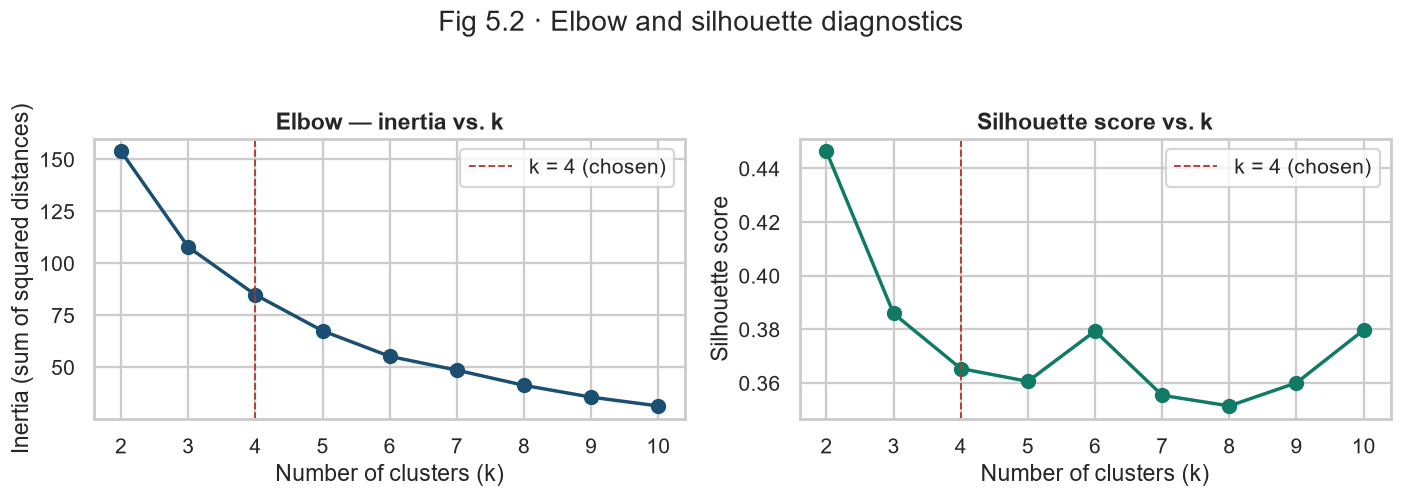

 k  inertia  silhouette
 2   153.82       0.446
 3   107.83       0.386
 4    84.84       0.365
 5    67.50       0.361
 6    55.22       0.379
 7    48.57       0.355
 8    41.26       0.351
 9    35.59       0.360
10    31.35       0.380


In [60]:
ks = list(range(2, 11))
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cluster)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(ks, inertias, marker="o", color="#1B4F72")
axes[0].axvline(4, color="#B03A2E", linestyle="--", linewidth=1.2, label="k = 4 (chosen)")
axes[0].set_title("Elbow — inertia vs. k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (sum of squared distances)")
axes[0].legend()

axes[1].plot(ks, sils, marker="o", color="#117A65")
axes[1].axvline(4, color="#B03A2E", linestyle="--", linewidth=1.2, label="k = 4 (chosen)")
axes[1].set_title("Silhouette score vs. k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

fig.suptitle("Fig 5.2 · Elbow and silhouette diagnostics", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "5_2_elbow_silhouette")
plt.show()

diag_table = pd.DataFrame({"k": ks, "inertia": np.round(inertias, 2),
                            "silhouette": np.round(sils, 3)})
print(diag_table.to_string(index=False))


### 5.3 Fit K-Means and inspect the clusters

Each cluster is characterised by its centroid, size, role composition
and five representative players (those closest to the centroid).
Labels are assigned in the next subsection based on these
characteristics.

In [38]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_cluster)
value_df["Cluster_Id"] = kmeans.labels_

centroids_scaled = kmeans.cluster_centers_
centroids_orig   = cluster_scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_orig,
                             columns=["centroid_Overall_Score",
                                      "centroid_log_Auction_Price"])
centroids_df["centroid_Auction_Price_Cr"] = np.exp(
    centroids_df["centroid_log_Auction_Price"]
) / 100

cluster_profile = (
    value_df.groupby("Cluster_Id")
            .agg(size=("Player", "count"),
                 mean_score=("Overall_Score", "mean"),
                 median_price_cr=("Auction_Price_Cr", "median"),
                 mean_price_cr=("Auction_Price_Cr", "mean"),
                 pct_overseas=("Is_Overseas", "mean"))
            .round(2)
            .join(centroids_df.round(3))
            .sort_values("mean_score", ascending=False)
)
cluster_profile["pct_overseas"] = (100 * cluster_profile["pct_overseas"]).round(0).astype(int)
print("Cluster profile (sorted by mean performance score):")
display(cluster_profile)

print("\nRole composition (count of players per cluster × role):")
role_by_cluster = pd.crosstab(value_df["Cluster_Id"], value_df["Role"])[role_order]
display(role_by_cluster)


Cluster profile (sorted by mean performance score):


,size,mean_score,median_price_cr,mean_price_cr,pct_overseas,centroid_Overall_Score,centroid_log_Auction_Price,centroid_Auction_Price_Cr
Cluster_Id,,,,,,,,
0,22,1.45,6.88,8.69,36,1.452,6.323,5.575
3,40,0.41,7.50,8.12,45,0.414,6.578,7.187
2,52,0.06,1.70,1.78,46,0.064,5.067,1.587
1,50,-0.37,0.30,0.42,14,-0.375,3.650,0.385



Role composition (count of players per cluster × role):


Role,Batter,Wicket-keeper,All-rounder,Bowler
Cluster_Id,,,,
0,9,7,1,5
1,7,4,22,17
2,7,3,19,23
3,5,3,12,20


In [39]:
from scipy.spatial.distance import cdist

reps_rows = []
for cid in range(K):
    mask = value_df["Cluster_Id"] == cid
    dists = cdist(X_cluster[mask.values], kmeans.cluster_centers_[[cid]]).ravel()
    idx = value_df.index[mask][np.argsort(dists)[:5]]
    reps = value_df.loc[idx, ["Player", "Role", "Country",
                              "Overall_Score", "Auction_Price_Cr"]].copy()
    reps.insert(0, "Cluster_Id", cid)
    reps_rows.append(reps)

representatives = pd.concat(reps_rows, ignore_index=True).round(
    {"Overall_Score": 2, "Auction_Price_Cr": 2}
)
print("Representative players (5 closest to each centroid):")
display(representatives)


Representative players (5 closest to each centroid):


,Cluster_Id,Player,Role,Country,Overall_Score,Auction_Price_Cr
0,0,Q de Kock,Wicket-keeper,South Africa,1.53,3.60
1,0,HV Patel,Bowler,India,1.22,8.00
2,0,DA Miller,Batter,South Africa,1.18,7.50
3,0,N Rana,Batter,India,1.14,4.20
4,0,K Rabada,Bowler,South Africa,1.40,10.75
5,1,AS Roy,All-rounder,India,-0.27,0.40
6,1,Zeeshan Ansari,Bowler,India,-0.49,0.40
7,1,Suryansh Shedge,All-rounder,India,-0.34,0.30
8,1,Abhinandan Singh,Bowler,India,-0.32,0.30
9,1,Swapnil Singh,All-rounder,India,-0.33,0.50


### 5.4 Assign cluster labels

Labels derived from each centroid's position on the score-vs-price
plane:

| Cluster | Centroid (score, ₹ Cr) | Size | Label |
|---|---|---:|---|
| 0 | (+1.45, 5.6) | 22 | Undervalued / High-value |
| 3 | (+0.41, 7.2) | 40 | High-performing but Expensive |
| 2 | (+0.06, 1.6) | 52 | Fair-value Mid-market |
| 1 | (−0.38, 0.4) | 50 | Low-cost / Low-impact |

In [40]:
CLUSTER_LABELS = {
    0: "Undervalued / High-value",
    3: "High-performing but Expensive",
    2: "Fair-value Mid-market",
    1: "Low-cost / Low-impact",
}
CLUSTER_COLORS = {
    "Undervalued / High-value":       "#117A65",
    "High-performing but Expensive":  "#B03A2E",
    "Fair-value Mid-market":          "#B7950B",
    "Low-cost / Low-impact":          "#5D6D7E",
}
CLUSTER_ORDER = [
    "Undervalued / High-value",
    "High-performing but Expensive",
    "Fair-value Mid-market",
    "Low-cost / Low-impact",
]

value_df["Value_Cluster"] = value_df["Cluster_Id"].map(CLUSTER_LABELS)

label_summary = (
    value_df.groupby("Value_Cluster")
            .agg(size=("Player", "count"),
                 mean_score=("Overall_Score", "mean"),
                 median_price_cr=("Auction_Price_Cr", "median"),
                 mean_price_cr=("Auction_Price_Cr", "mean"),
                 pct_overseas=("Is_Overseas", "mean"))
            .round(2)
            .reindex(CLUSTER_ORDER)
)
label_summary["pct_overseas"] = (100 * label_summary["pct_overseas"]).round(0).astype(int)
label_summary


,size,mean_score,median_price_cr,mean_price_cr,pct_overseas
Value_Cluster,,,,,
Undervalued / High-value,22,1.45,6.88,8.69,36
High-performing but Expensive,40,0.41,7.50,8.12,45
Fair-value Mid-market,52,0.06,1.70,1.78,46
Low-cost / Low-impact,50,-0.37,0.30,0.42,14


### 5.5 Value-efficiency map

Every player positioned on the performance-score × auction-price
plane, coloured by value cluster. Dashed reference lines mark the
population median score and median price and carve the plane into
four quadrants.

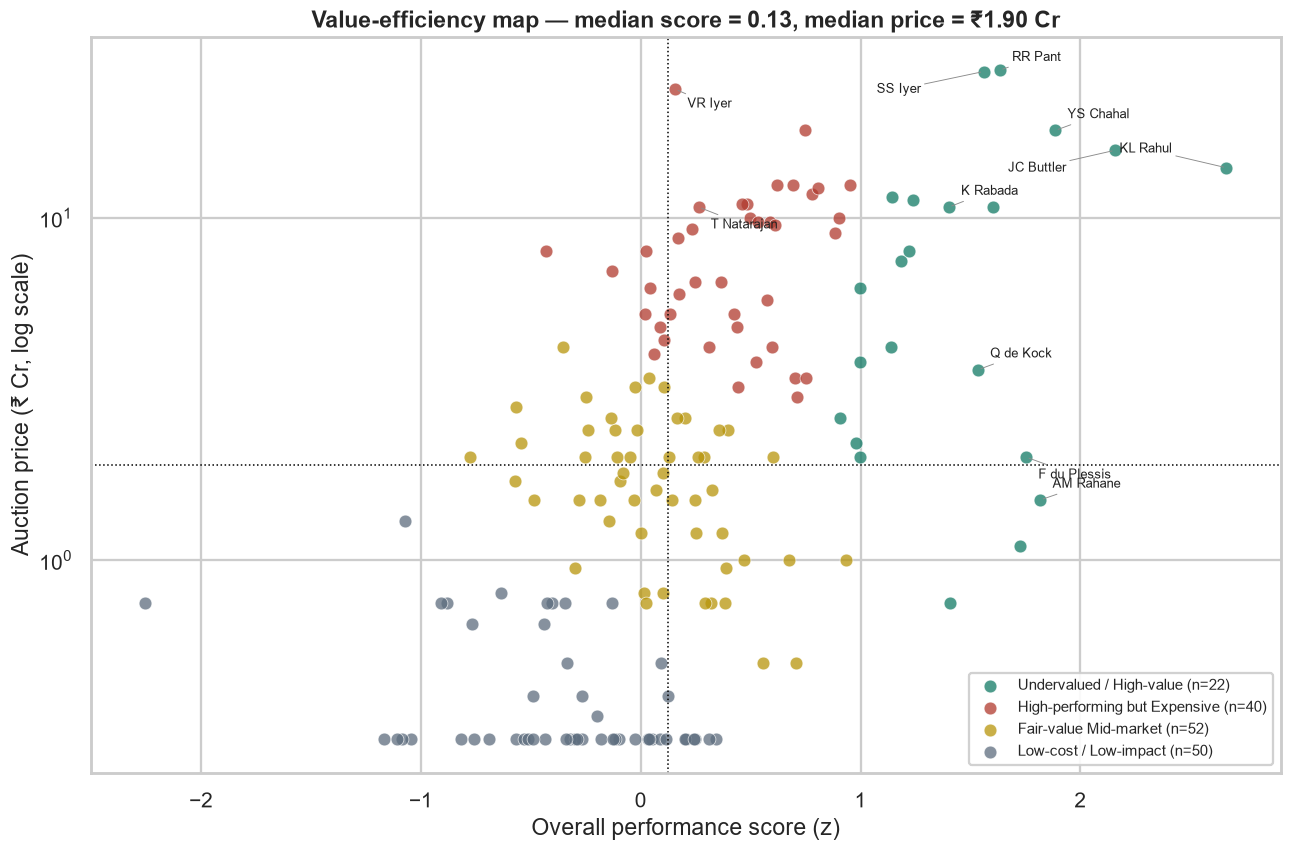

In [61]:
annotate = {
    # name: (dx, dy) label offset in points
    "RR Pant":       (8, 6),
    "SS Iyer":       (-70, -14),
    "VR Iyer":       (8, -12),
    "KL Rahul":      (-70, 10),
    "JC Buttler":    (-70, -14),
    "YS Chahal":     (8, 8),
    "AM Rahane":     (8, 8),
    "F du Plessis":  (8, -14),
    "Q de Kock":     (8, 8),
    "K Rabada":      (8, 8),
    "T Natarajan":   (8, -14),
    "VR Iyer":       (8, -12),
}

fig, ax = plt.subplots(figsize=(12, 8))
for cluster_name in CLUSTER_ORDER:
    sub = value_df[value_df["Value_Cluster"] == cluster_name]
    ax.scatter(sub["Overall_Score"], sub["Auction_Price_Cr"],
               s=70, alpha=0.75, edgecolor="white", linewidth=0.5,
               color=CLUSTER_COLORS[cluster_name],
               label=f"{cluster_name} (n={len(sub)})")

score_median = value_df["Overall_Score"].median()
price_median = value_df["Auction_Price_Cr"].median()
ax.axhline(price_median, color="black", linestyle=":", linewidth=1)
ax.axvline(score_median, color="black", linestyle=":", linewidth=1)

for name, (dx, dy) in annotate.items():
    row = value_df[value_df["Player"] == name]
    if row.empty:
        continue
    row = row.iloc[0]
    ax.annotate(
        name,
        xy=(row["Overall_Score"], row["Auction_Price_Cr"]),
        xytext=(dx, dy), textcoords="offset points",
        fontsize=8.5, color="#212121",
        arrowprops=dict(arrowstyle="-", color="#8c8c8c",
                        lw=0.6, shrinkA=0, shrinkB=2),
    )

ax.set_yscale("log")
ax.set_xlabel("Overall performance score (z)")
ax.set_ylabel("Auction price (₹ Cr, log scale)")
ax.set_title(f"Value-efficiency map — median score = {score_median:.2f}, "
             f"median price = ₹{price_median:.2f} Cr")
ax.legend(title="", loc="lower right", fontsize=10, framealpha=0.9)

fig.tight_layout()
save_fig(fig, "5_5_value_efficiency_map")
plt.show()


### 5.6 Save the clustered dataset

Written to `data/processed/ipl_player_valuation.csv`.

In [42]:
valuation_path = PROCESSED_DIR / "ipl_player_valuation.csv"
value_df.to_csv(valuation_path, index=False)

print(f"Saved: {valuation_path.relative_to(PROJECT_ROOT)}")
print(f"Shape: {value_df.shape}")
print(f"New columns added in Phase 5: Cluster_Id, Value_Cluster")
print("\nCluster totals:")
print(value_df["Value_Cluster"].value_counts().reindex(CLUSTER_ORDER).to_string())


Saved: data\processed\ipl_player_valuation.csv
Shape: (164, 52)
New columns added in Phase 5: Cluster_Id, Value_Cluster

Cluster totals:
Value_Cluster
Undervalued / High-value         22
High-performing but Expensive    40
Fair-value Mid-market            52
Low-cost / Low-impact            50


## 6. Business insights and recommendations

Converts the clustered dataset into a ranked shortlist, a watch-list
and role- and franchise-level cross-tabulations, followed by written
recommendations grounded in those tables.

The ranking metric is the standardised gap between measured
performance and paid price:

$$
\text{Value\_Gap} = z(\text{Overall\_Score}) - z(\log \text{Auction\_Price\_Lakh})
$$

A large positive `Value_Gap` means the player performed materially
better than the paid price implies; a large negative `Value_Gap`
means the paid price is elevated relative to measured performance.
The interpretation is relative to the 2025 auction population, not
an absolute claim of market failure.

### 6.1 Compute the Value Gap

In [43]:
insights = pd.read_csv(PROCESSED_DIR / "ipl_player_valuation.csv")

score_z = (insights["Overall_Score"] - insights["Overall_Score"].mean()) / insights["Overall_Score"].std(ddof=0)
price_z = (insights["log_Auction_Price"] - insights["log_Auction_Price"].mean()) / insights["log_Auction_Price"].std(ddof=0)
insights["Value_Gap"] = (score_z - price_z).round(3)

print("Value_Gap distribution:")
print(insights["Value_Gap"].describe().round(3).to_string())


Value_Gap distribution:
count    164.000
mean      -0.000
std        0.935
min       -2.862
25%       -0.696
50%       -0.095
75%        0.646
max        2.546


### 6.2 Top-value shortlist

The 15 players with the largest positive `Value_Gap`. The
`Low_Sample` flag identifies players with fewer than 10 IPL matches so
their score is interpreted with the appropriate caveat.

In [44]:
top_value = (
    insights.sort_values("Value_Gap", ascending=False)
            .head(15)
            [["Player", "Role", "Country", "Mat",
              "Overall_Score", "Performance_Tier",
              "Auction_Price_Cr", "Auction_Team",
              "Value_Cluster", "Value_Gap", "Low_Sample"]]
            .round({"Overall_Score": 2, "Auction_Price_Cr": 2})
            .reset_index(drop=True)
)
print("Top 15 by Value Gap — franchises got materially more performance than the price implies:")
top_value


Top 15 by Value Gap — franchises got materially more performance than the price implies:


,Player,Role,Country,Mat,Overall_Score,Performance_Tier,Auction_Price_Cr,Auction_Team,Value_Cluster,Value_Gap,Low_Sample
0,V Sooryavanshi,Batter,India,23,1.73,High,1.10,Rajasthan Royals,Undervalued / High-value,2.546,0
1,AM Rahane,Batter,India,212,1.82,High,1.50,Kolkata Knight Riders,Undervalued / High-value,2.440,0
2,MK Pandey,Batter,India,180,1.41,High,0.75,Kolkata Knight Riders,Undervalued / High-value,2.383,0
3,F du Plessis,Batter,South Africa,154,1.75,High,2.00,Delhi Capitals,Undervalued / High-value,2.127,0
4,KL Rahul,Wicket-keeper,India,159,2.66,High,14.00,Delhi Capitals,Undervalued / High-value,1.937,0
5,KK Nair,Batter,India,86,0.71,High,0.50,Delhi Capitals,Fair-value Mid-market,1.690,0
6,Ashwani Kumar,Bowler,India,10,0.34,Medium,0.30,Mumbai Indians,Low-cost / Low-impact,1.566,0
7,RS Hangargekar,All-rounder,India,2,0.31,Medium,0.30,Lucknow Super Giants,Low-cost / Low-impact,1.515,1
8,RD Rickelton,Wicket-keeper,South Africa,26,0.93,High,1.00,Mumbai Indians,Fair-value Mid-market,1.484,0
9,KV Sharma,Bowler,India,90,0.56,High,0.50,Mumbai Indians,Fair-value Mid-market,1.476,0


### 6.3 Watch-list

The 10 players with the largest negative `Value_Gap`. This is a
data-driven watch-list of acquisitions where the paid price is
elevated relative to measured performance, not a claim of absolute
overpayment.

In [45]:
watch_list = (
    insights.sort_values("Value_Gap", ascending=True)
            .head(10)
            [["Player", "Role", "Country", "Mat",
              "Overall_Score", "Performance_Tier",
              "Auction_Price_Cr", "Auction_Team",
              "Value_Cluster", "Value_Gap", "Low_Sample"]]
            .round({"Overall_Score": 2, "Auction_Price_Cr": 2})
            .reset_index(drop=True)
)
print("Bottom 10 by Value Gap — paid price is elevated relative to measured performance:")
watch_list


Bottom 10 by Value Gap — paid price is elevated relative to measured performance:


,Player,Role,Country,Mat,Overall_Score,Performance_Tier,Auction_Price_Cr,Auction_Team,Value_Cluster,Value_Gap,Low_Sample
0,Karim Janat,All-rounder,Afghanistan,1,-2.25,Low,0.75,Gujarat Titans,Low-cost / Low-impact,-2.862,1
1,Akash Deep,Bowler,India,14,-0.43,Low,8.00,Lucknow Super Giants,High-performing but Expensive,-2.071,0
2,VR Iyer,All-rounder,India,69,0.16,Medium,23.75,Kolkata Knight Riders,High-performing but Expensive,-2.063,0
3,Gurnoor Brar,Bowler,India,1,-1.07,Low,1.30,Gujarat Titans,Low-cost / Low-impact,-1.594,1
4,M Jansen,All-rounder,South Africa,48,-0.13,Low,7.00,Punjab Kings,High-performing but Expensive,-1.539,0
5,Fazalhaq Farooqi,Bowler,Afghanistan,12,-0.78,Low,2.00,Rajasthan Royals,Fair-value Mid-market,-1.501,0
6,Abdul Samad,All-rounder,India,71,-0.35,Low,4.20,Lucknow Super Giants,Fair-value Mid-market,-1.464,0
7,SH Johnson,Bowler,Australia,12,-0.57,Low,2.80,Kolkata Knight Riders,Fair-value Mid-market,-1.455,0
8,Mukesh Kumar,Bowler,India,42,0.02,Medium,8.00,Delhi Capitals,High-performing but Expensive,-1.420,0
9,T Natarajan,Bowler,India,73,0.26,Medium,10.75,Delhi Capitals,High-performing but Expensive,-1.302,0


### 6.4 Role × Value Cluster

In [46]:
role_cluster_counts = (
    pd.crosstab(insights["Role"], insights["Value_Cluster"])
      .reindex(index=role_order, columns=CLUSTER_ORDER)
      .fillna(0)
      .astype(int)
)
role_cluster_share = (
    pd.crosstab(insights["Role"], insights["Value_Cluster"], normalize="index")
      .reindex(index=role_order, columns=CLUSTER_ORDER)
      .fillna(0)
      * 100
).round(0).astype(int)

print("Role × Value cluster — player counts:")
display(role_cluster_counts)

print("\nRole × Value cluster — % of role:")
display(role_cluster_share)


Role × Value cluster — player counts:


Value_Cluster,Undervalued / High-value,High-performing but Expensive,Fair-value Mid-market,Low-cost / Low-impact
Role,,,,
Batter,9,5,7,7
Wicket-keeper,7,3,3,4
All-rounder,1,12,19,22
Bowler,5,20,23,17



Role × Value cluster — % of role:


Value_Cluster,Undervalued / High-value,High-performing but Expensive,Fair-value Mid-market,Low-cost / Low-impact
Role,,,,
Batter,32,18,25,25
Wicket-keeper,41,18,18,24
All-rounder,2,22,35,41
Bowler,8,31,35,26


### 6.5 Franchise × Value Cluster

Count of players per franchise per cluster, sorted by number of
*Undervalued / High-value* acquisitions.

In [47]:
team_cluster_counts = (
    pd.crosstab(insights["Auction_Team"], insights["Value_Cluster"])
      .reindex(columns=CLUSTER_ORDER)
      .fillna(0)
      .astype(int)
)
team_cluster_counts["Total_buys"] = team_cluster_counts.sum(axis=1)
team_cluster_counts["Undervalued_share_%"] = (
    100 * team_cluster_counts["Undervalued / High-value"]
    / team_cluster_counts["Total_buys"]
).round(0).astype(int)
team_cluster_counts = team_cluster_counts.sort_values(
    ["Undervalued / High-value", "Undervalued_share_%"], ascending=False
)

print("Franchise × Value cluster — player counts (sorted by Undervalued count):")
display(team_cluster_counts)


Franchise × Value cluster — player counts (sorted by Undervalued count):


Value_Cluster,Undervalued / High-value,High-performing but Expensive,Fair-value Mid-market,Low-cost / Low-impact,Total_buys,Undervalued_share_%
Auction_Team,,,,,,
Punjab Kings,4,5,7,4,20,20
Kolkata Knight Riders,3,3,5,2,13,23
Delhi Capitals,3,6,3,5,17,18
Royal Challengers Bengaluru,3,5,6,4,18,17
Sunrisers Hyderabad,2,2,5,4,13,15
Rajasthan Royals,2,4,4,4,14,14
Lucknow Super Giants,2,3,4,7,16,12
Gujarat Titans,2,2,8,8,20,10
Chennai Super Kings,1,5,7,5,18,6


### 6.6 Save the insight artefacts

In [48]:
insights.to_csv(PROCESSED_DIR / "ipl_player_valuation.csv", index=False)
top_value.to_csv(PROCESSED_DIR / "top_value_shortlist.csv", index=False)
watch_list.to_csv(PROCESSED_DIR / "overpriced_watchlist.csv", index=False)

print("Saved artefacts:")
for name in ["ipl_player_valuation.csv",
             "top_value_shortlist.csv",
             "overpriced_watchlist.csv"]:
    p = PROCESSED_DIR / name
    print(f"  - {p.relative_to(PROJECT_ROOT)}  ({p.stat().st_size:,} bytes)")


Saved artefacts:
  - data\processed\ipl_player_valuation.csv  (56,618 bytes)
  - data\processed\top_value_shortlist.csv  (1,553 bytes)
  - data\processed\overpriced_watchlist.csv  (1,126 bytes)


### 6.7 Recommendations

**1. Prioritise wicket-keepers and specialist batters in the
shortlist.**
41% of wicket-keepers (7 of 17) and 32% of batters (9 of 28) in the
2025 dataset land in the *Undervalued / High-value* cluster, versus
8% of bowlers and 2% of all-rounders. A value-first shortlist should
therefore start with keepers and batters and add bowlers or
all-rounders only where a specific candidate shows a strong
`Value_Gap` relative to peers in the same role cluster.

**2. Treat the ₹6–15 Cr price band as a high-scrutiny zone.**
The same band contains both the strongest value in the dataset
(KL Rahul at ₹14 Cr, Overall Score 2.66) and the largest individual
watch-list flags (VR Iyer at ₹23.75 Cr with Overall Score 0.16,
T Natarajan at ₹10.75 Cr with Overall Score 0.26, Akash Deep at ₹8 Cr
with Overall Score −0.43). Any acquisition above ₹5 Cr merits a
peer comparison inside its role cluster before the bid is placed.

**3. Question the all-rounder tag.**
Only 1 of 54 all-rounders (2%) qualified as Undervalued, while 22 of
54 (41%) sit in *Low-cost / Low-impact*. The all-rounder premium is
often paid for players who do not truly excel at either discipline.
Replacing the generic "all-rounder" target with an explicit sub-target
(bowling all-rounder with a wickets-per-match floor, or batting
all-rounder with a runs-per-innings floor) removes this exposure.

**4. Benchmark PBKS and KKR on value capture.**
The franchise cross-tabulation ranks Undervalued acquisitions per
buyer:

| Franchise | Undervalued | Total buys | Undervalued share |
|---|---:|---:|---:|
| Punjab Kings              | 4 | 20 | 20% |
| Kolkata Knight Riders     | 3 | 13 | 23% |
| Delhi Capitals            | 3 | 17 | 18% |
| Royal Challengers Bengaluru | 3 | 18 | 17% |
| Sunrisers Hyderabad       | 2 | 13 | 15% |
| Rajasthan Royals          | 2 | 14 | 14% |
| Lucknow Super Giants      | 2 | 16 | 12% |
| Gujarat Titans            | 2 | 20 | 10% |
| Chennai Super Kings       | 1 | 18 | 6% |
| Mumbai Indians            | 0 | 15 | 0% |

Punjab Kings and Kolkata Knight Riders lead on absolute count and
share respectively. Mumbai Indians captured zero Undervalued
acquisitions and Chennai Super Kings only one — a specific finding
worth an internal audit rather than a general judgment, given both
franchises used a large share of their purse on retentions before
the auction.

---

**Artefacts produced:**

* `data/processed/ipl_player_valuation.csv` — one row per player with
  score, tier, value cluster and `Value_Gap`.
* `data/processed/top_value_shortlist.csv` — top 15 by `Value_Gap`.
* `data/processed/overpriced_watchlist.csv` — bottom 10 by `Value_Gap`.
* `notebooks/figures/` — all figures used in the analysis.